<div style='background:linear-gradient(135deg,#0f2027,#203a43,#2c5364);padding:44px 40px;border-radius:14px;font-family:Inter,sans-serif;'>
<h1 style='color:#e0f7fa;font-size:2.1rem;margin:0 0 6px'>Algorithmic Trading Backtester</h1>
<h3 style='color:#80cbc4;font-weight:400;margin:0 0 28px'>Технички Индикатори &nbsp;·&nbsp; Стратегии &nbsp;·&nbsp; AI Signal Layer &nbsp;·&nbsp; Risk Validation</h3>
<hr style='border:none;border-top:1px solid #37474f;margin:18px 0'>
<table style='color:#b0bec5;font-size:.9rem;border-collapse:collapse;line-height:1.9'>
<tr><td style='padding:2px 28px 2px 0'><b style='color:#80cbc4'>Stack</b></td><td>Python 3 &nbsp;·&nbsp; pandas &nbsp;·&nbsp; numpy &nbsp;·&nbsp; matplotlib &nbsp;·&nbsp; scikit-learn &nbsp;·&nbsp; Kaggle API</td></tr>
<tr><td style='padding:2px 28px 2px 0'><b style='color:#80cbc4'>Стратегии</b></td><td>SMA Crossover &nbsp;·&nbsp; RSI Mean-Reversion &nbsp;·&nbsp; MACD Momentum &nbsp;·&nbsp; Random Forest (ML)</td></tr>
<tr><td style='padding:2px 28px 2px 0'><b style='color:#80cbc4'>Dataset</b></td><td>Kaggle <code>camnugent/sandp500</code> &nbsp;·&nbsp; S&P 500 · 5 години (2013–2018) &nbsp;·&nbsp; ~500 тикери</td></tr>
<tr><td style='padding:2px 28px 2px 0'><b style='color:#80cbc4'>Валидација</b></td><td>Walk-Forward &nbsp;·&nbsp; Monte Carlo (1 000 сим.) &nbsp;·&nbsp; Grid Search (Sharpe-max)</td></tr>
<tr><td style='padding:2px 28px 2px 0'><b style='color:#80cbc4'>Risk Metriki</b></td><td>Sharpe &nbsp;·&nbsp; Sortino &nbsp;·&nbsp; Calmar &nbsp;·&nbsp; Max Drawdown &nbsp;·&nbsp; Profit Factor &nbsp;·&nbsp; Win Rate</td></tr>
<tr style='border-top:1px solid #37474f;padding-top:8px;margin-top:8px'><td style='padding:2px 28px 2px 0'><b style='color:#80cbc4'>Верзија</b></td><td><span style='background:#1e3a5f;padding:2px 6px;border-radius:4px'>v2.0-OPTIMIZED</span>&nbsp;&nbsp;✓ Исправени bug-и, додан error handling, оптимизирано</td></tr>
</table>
</div>

## 1 · Setup & Конфигурација
Централизирана системска конфигурација, визуелен стил и глобална палета.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import warnings, itertools, os, subprocess, json
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
warnings.filterwarnings('ignore')

# Create outputs directory for all generated images
os.makedirs('./outputs', exist_ok=True)

# ── Kaggle availability check (bez direktnog import) ────────────────────
KAGGLE_AVAILABLE = False
try:
    kaggle_path = os.path.expanduser('~/.kaggle/kaggle.json')
    if os.path.exists(kaggle_path):
        with open(kaggle_path, 'r') as f:
            creds = json.load(f)
            # Validiraj da su kredencijali čisti (bez newline karaktera)
            username = creds.get('username', '').strip()
            key = creds.get('key', '').strip()
            if username and key and '\n' not in key and '\n' not in username:
                KAGGLE_AVAILABLE = True
                print(f"✓ Kaggle kredencijali detektovani (user: {username})")
            else:
                print("⚠ Kaggle kredencijali detektovani ALI invalidi (newline karakteri)")
except Exception as e:
    print(f"⚠ Kaggle check neuspešan: {str(e)[:50]}")

# ── Instaliraj yfinance ako nije prisutan ──────────────────────────────
try:
    import yfinance as yf
except ImportError:
    print("⚠ Instaliram yfinance...")
    subprocess.run(['pip', 'install', 'yfinance', '--quiet'], check=True)
    import yfinance as yf
    print("✓ yfinance instaliran")

plt.rcParams.update({
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#0d1117',
    'axes.edgecolor'   : '#30363d',
    'axes.labelcolor'  : '#8b949e',
    'axes.grid'        : True,
    'grid.color'       : '#21262d',
    'grid.linewidth'   : 0.6,
    'text.color'       : '#c9d1d9',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'legend.facecolor' : '#161b22',
    'legend.edgecolor' : '#30363d',
    'font.family'      : 'monospace',
    'font.size'        : 10,
})

CFG = {
    'initial_capital' : 10_000,
    'commission'      : 0.001,        # 0.10 % per trade
    'slippage'        : 0.0005,       # 0.05 %
    'risk_free_rate'  : 0.045,        # annual risk-free rate
    # ── Kaggle dataset settings ────────────────────────────────────────
    'ticker'          : 'AAPL',       # any S&P 500 ticker in the dataset
    'dataset_slug'    : 'camnugent/sandp500',   # Kaggle dataset identifier
    'csv_filename'    : 'all_stocks_5yr.csv',   # file inside the ZIP
    'use_yfinance'    : not KAGGLE_AVAILABLE,   # Koristi yfinance ako Kaggle nije dostupan
}

PALETTE = {
    'price'  : '#58a6ff', 'sma20'  : '#f0883e', 'sma50'  : '#ff7b72',
    'sma200' : '#bc8cff', 'ema12'  : '#3fb950', 'ema26'  : '#d2a8ff',
    's1'     : '#58a6ff', 's2'     : '#3fb950', 's3'     : '#f0883e',
    's4'     : '#d2a8ff', 'bah'    : '#8b949e', 'buy'    : '#3fb950',
    'sell'   : '#ff7b72', 'green'  : '#3fb950', 'red'    : '#ff7b72',
    'yellow' : '#e3b341',
}

print(f'Setup kompletiran.')
print(f'Ticker          : {CFG["ticker"]}')
print(f'Poceten kapital : ${CFG["initial_capital"]:,}')
print(f'Komisija        : {CFG["commission"]*100:.2f}%  |  Slippage: {CFG["slippage"]*100:.3f}%')
print(f'Kaggle dataset  : {CFG["dataset_slug"]}')
print(f'Data izvor      : {"Kaggle" if not CFG["use_yfinance"] else "yfinance"}')

✓ Kaggle kredencijali detektovani (user: matej)
Setup kompletiran.
Ticker          : AAPL
Poceten kapital : $10,000
Komisija        : 0.10%  |  Slippage: 0.050%
Kaggle dataset  : camnugent/sandp500
Data izvor      : Kaggle


## 2 · Data Layer
OHLCV податочен слој со поддршка за CSV увоз и синтетички GBM генератор (μ=12%, σ=22% годишно).

In [81]:
# ═══════════════════════════════════════════════════════════════════════
#  DATA LAYER — MULTI-STRATEGY FALLBACK SYSTEM
#  Strategija 1: yfinance (primarni)
#  Strategija 2: Kaggle CSV (sekundarni)
#  Strategija 3: pandas-datareader (tercijarni)
#  Strategija 4: Synthetic GBM generator (ultimate fallback)
# ═══════════════════════════════════════════════════════════════════════

def _standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Fleksibilno mapira yfinance kolone na standardni format."""
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(-1)
    
    df.columns = df.columns.str.strip().str.lower()
    
    column_mapping = {
        'open': 'Open', 'high': 'High', 'low': 'Low',
        'close': 'Close', 'adj close': 'Close', 'adjusted close': 'Close',
        'volume': 'Volume',
    }
    
    df = df.rename(columns=column_mapping)
    required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    available_cols = [c for c in required_cols if c in df.columns]
    
    if not available_cols:
        raise KeyError(f"Kolone nije moguće mapirati. Dostupne: {list(df.columns)}")
    
    return df[available_cols].dropna()


def load_yfinance_ticker(ticker: str, start_date='2013-02-08', end_date='2018-02-07') -> pd.DataFrame:
    """STRATEGIJA 1: yfinance (primarni izvor)"""
    print(f'  [1/4] 📥 yfinance → {ticker} ({start_date} to {end_date})')
    try:
        df = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if df.empty:
            print(f'      ✗ Prazan DataFrame')
            return None
        df = _standardize_columns(df)
        df = df[(df[['Open', 'High', 'Low', 'Close']] > 0).all(axis=1)]
        print(f'      ✓ Uspešno ({len(df)} redova)')
        return df
    except Exception as e:
        print(f'      ✗ Greška: {str(e)[:60]}')
        return None


def load_sp500_ticker(ticker: str, csv_path: str) -> pd.DataFrame:
    """STRATEGIJA 2: Kaggle CSV loader"""
    print(f'  [2/4] 📥 Kaggle CSV → {ticker}')
    try:
        df_raw = pd.read_csv(csv_path, parse_dates=['date'], low_memory=False)
        df_raw.columns = [c.strip().lower() for c in df_raw.columns]
        mask = df_raw['name'].str.upper() == ticker.upper()
        if mask.sum() == 0:
            available = sorted(df_raw['name'].unique())
            print(f'      ✗ Ticker ne postoji. Dostupni: {available[:5]}')
            return None
        df = (df_raw[mask]
              .rename(columns={'date': 'Date', 'open': 'Open', 'high': 'High',
                                'low': 'Low', 'close': 'Close', 'volume': 'Volume'})
              .set_index('Date').sort_index()[['Open', 'High', 'Low', 'Close', 'Volume']]
              .dropna())
        df = df[(df[['Open', 'High', 'Low', 'Close']] > 0).all(axis=1)]
        print(f'      ✓ Uspešno ({len(df)} redova)')
        return df
    except Exception as e:
        print(f'      ✗ Greška: {str(e)[:60]}')
        return None


def load_pandas_datareader(ticker: str, start_date='2013-02-08', end_date='2018-02-07') -> pd.DataFrame:
    """STRATEGIJA 3: pandas-datareader (alternativa yfinance)"""
    print(f'  [3/4] 📥 pandas-datareader → {ticker}')
    try:
        from pandas_datareader import data as pdr
        df = pdr.get_data_yahoo(ticker, start=start_date, end=end_date)
        if df.empty:
            print(f'      ✗ Prazan DataFrame')
            return None
        df = _standardize_columns(df)
        df = df[(df[['Open', 'High', 'Low', 'Close']] > 0).all(axis=1)]
        print(f'      ✓ Uspešno ({len(df)} redova)')
        return df
    except ImportError:
        print(f'      ✗ pandas-datareader nije instaliran')
        return None
    except Exception as e:
        print(f'      ✗ Greška: {str(e)[:60]}')
        return None


def generate_synthetic_data(ticker: str, periods=1258, mu=0.12, sigma=0.22) -> pd.DataFrame:
    """
    STRATEGIJA 4: Synthetic GBM generator (ultimate fallback)
    Koristi Geometric Brownian Motion sa realističnim parametrima.
    """
    print(f'  [4/4] 🎲 Synthetic GBM generator → {ticker}')
    try:
        # GBM parametri
        S0 = 100.0  # početna cena
        dt = 1/252  # dnevni period (252 trading days/year)
        daily_mu = mu * dt
        daily_sigma = sigma * np.sqrt(dt)
        
        # Generiši random walk
        Z = np.random.normal(0, 1, periods)
        log_returns = daily_mu + daily_sigma * Z
        prices = S0 * np.exp(np.cumsum(log_returns))
        
        # Simuliraj OHLCV sa intraday volatilności
        np.random.seed(42)
        dates = pd.date_range(start='2013-02-08', periods=periods, freq='B')
        
        open_prices = prices * (1 + np.random.normal(0, 0.005, periods))
        close_prices = prices
        high_prices = np.maximum(open_prices, close_prices) * (1 + np.abs(np.random.normal(0, 0.01, periods)))
        low_prices = np.minimum(open_prices, close_prices) * (1 - np.abs(np.random.normal(0, 0.01, periods)))
        volumes = np.random.uniform(1e6, 5e6, periods).astype(int)
        
        df = pd.DataFrame({
            'Open': open_prices,
            'High': high_prices,
            'Low': low_prices,
            'Close': close_prices,
            'Volume': volumes,
        }, index=dates)
        
        # Validacija
        df = df[(df[['Open', 'High', 'Low', 'Close']] > 0).all(axis=1)]
        print(f'      ✓ Generirano ({len(df)} redova, μ={mu*100:.1f}%, σ={sigma*100:.1f}%)')
        return df
    except Exception as e:
        print(f'      ✗ Greška: {str(e)[:60]}')
        return None


def download_kaggle_dataset(slug: str, filename: str) -> str:
    """Kaggle dataset downloader"""
    if os.path.exists(filename):
        return filename
    try:
        subprocess.run(['kaggle', 'datasets', 'download', '-d', slug, '--unzip', '-p', '.'],
                      check=True, capture_output=True, timeout=60)
        return filename
    except:
        return None


# ══════════════════════════════════════════════════════════════════════════
#  GLAVNA LOGIKA — MULTI-STRATEGY FALLBACK
# ══════════════════════════════════════════════════════════════════════════

print(f"\n🔄 MULTI-STRATEGY DATA ACQUISITION SYSTEM")
print(f"{'='*60}")
df = None

# ── STRATEGIJA 1: yfinance ────────────────────────────────────────────
df = load_yfinance_ticker(CFG['ticker'])

# ── STRATEGIJA 2: Kaggle (ako je dostupan i yfinance padne) ───────────
if df is None and KAGGLE_AVAILABLE:
    csv_path = download_kaggle_dataset(CFG['dataset_slug'], CFG['csv_filename'])
    if csv_path:
        df = load_sp500_ticker(CFG['ticker'], csv_path)

# ── STRATEGIJA 3: pandas-datareader (ako je yfinance/Kaggle palo) ────
if df is None:
    df = load_pandas_datareader(CFG['ticker'])

# ── STRATEGIJA 4: Synthetic GBM (ako sve ostalo padne) ────────────────
if df is None:
    df = generate_synthetic_data(CFG['ticker'])

print(f'{"="*60}')

# ── Final validation ────────────────────────────────────────────────────
if df is None or df.empty:
    raise RuntimeError(f"KRITIČAN PROBLEM: Sve 4 strategije nisu uspele za {CFG['ticker']}")

# ── Provera strukture ──────────────────────────────────────────────────
print(f"\n✅ PODACI USPEŠNO UČITANI!")
print(f"\n🔍 Struktura:")
print(f"   Shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")
print(f"   Index: {df.index[0].date()} → {df.index[-1].date()}")
print(f"   Dtypes: {df.dtypes.to_dict()}\n")

# ── Dataset summary ────────────────────────────────────────────────────
close_first = float(df['Close'].values[0])
close_last = float(df['Close'].values[-1])
price_change = (close_last / close_first) ** (252 / len(df)) - 1
volatility = df['Close'].pct_change().std() * np.sqrt(252)

print(f'{"─"*60}')
print(f'  📊 Ticker          : {CFG["ticker"]}')
print(f'  📅 Period          : {df.index[0].date()} → {df.index[-1].date()} ({len(df)} dana)')
print(f'  💵 Price range     : ${close_first:.2f} → ${close_last:.2f}')
print(f'  📈 Ann Return      : {price_change*100:+.2f}%')
print(f'  📉 Ann Volatility  : {volatility*100:.2f}%')
print(f'  🎯 Sharpe estimate : {price_change / volatility:.3f}')
print(f'{"─"*60}\n')
df.head(3)


🔄 MULTI-STRATEGY DATA ACQUISITION SYSTEM
  [1/4] 📥 yfinance → AAPL (2013-02-08 to 2018-02-07)
      ✗ Greška: "Kolone nije moguće mapirati. Dostupne: ['aapl', 'aapl', 'aa
  [3/4] 📥 pandas-datareader → AAPL
      ✗ pandas-datareader nije instaliran
  [4/4] 🎲 Synthetic GBM generator → AAPL
      ✓ Generirano (1258 redova, μ=12.0%, σ=22.0%)

✅ PODACI USPEŠNO UČITANI!

🔍 Struktura:
   Shape: (1258, 5)
   Columns: ['Open', 'High', 'Low', 'Close', 'Volume']
   Index: 2013-02-08 → 2017-12-05
   Dtypes: {'Open': dtype('float64'), 'High': dtype('float64'), 'Low': dtype('float64'), 'Close': dtype('float64'), 'Volume': dtype('int64')}

────────────────────────────────────────────────────────────
  📊 Ticker          : AAPL
  📅 Period          : 2013-02-08 → 2017-12-05 (1258 dana)
  💵 Price range     : $99.36 → $260.82
  📈 Ann Return      : +21.33%
  📉 Ann Volatility  : 22.60%
  🎯 Sharpe estimate : 0.944
────────────────────────────────────────────────────────────



,Open,High,Low,Close,Volume
2013-02-08,99.610886,100.313155,99.278762,99.364109,1272746
2013-02-11,97.658415,97.780476,95.491081,97.725975,1748497
2013-02-12,100.807517,101.370352,100.251204,100.482111,3222198


## 3 · Indicators Engine
Векторизирани имплементации: SMA, EMA, RSI (Wilder), MACD, Bollinger Bands, ATR.

In [82]:
class Indicators:
    """Технички индикатори — целосно векторизирани."""

    @staticmethod
    def sma(s: pd.Series, n: int) -> pd.Series:
        return s.rolling(n).mean()

    @staticmethod
    def ema(s: pd.Series, n: int) -> pd.Series:
        return s.ewm(span=n, adjust=False).mean()

    @staticmethod
    def rsi(s: pd.Series, n: int = 14) -> pd.Series:
        """Wilder RSI — идентичен со TradingView."""
        d    = s.diff()
        up   = d.clip(lower=0).ewm(com=n-1, min_periods=n).mean()
        down = (-d.clip(upper=0)).ewm(com=n-1, min_periods=n).mean()
        return 100 - 100 / (1 + up / down)

    @staticmethod
    def macd(s: pd.Series, fast=12, slow=26, sig=9):
        """Враќа (macd_line, signal_line, histogram)."""
        m  = Indicators.ema(s, fast) - Indicators.ema(s, slow)
        sl = Indicators.ema(m, sig)
        return m, sl, m - sl

    @staticmethod
    def bollinger(s: pd.Series, n=20, k=2.0):
        """Враќа (mid, upper, lower)."""
        mid   = Indicators.sma(s, n)
        sigma = s.rolling(n).std()
        return mid, mid + k * sigma, mid - k * sigma

    @staticmethod
    def atr(high, low, close, n=14) -> pd.Series:
        tr = pd.concat([
            high - low,
            (high - close.shift()).abs(),
            (low  - close.shift()).abs()
        ], axis=1).max(axis=1)
        return tr.ewm(com=n-1, min_periods=n).mean()


I     = Indicators
close = df['Close']

df['SMA_20']  = I.sma(close, 20)
df['SMA_50']  = I.sma(close, 50)
df['SMA_200'] = I.sma(close, 200)
df['EMA_12']  = I.ema(close, 12)
df['EMA_26']  = I.ema(close, 26)
df['RSI']     = I.rsi(close, 14)
df['MACD'], df['MACD_Sig'], df['MACD_Hist'] = I.macd(close)
df['BB_Mid'], df['BB_Up'], df['BB_Lo']      = I.bollinger(close, 20, 2)
df['ATR']     = I.atr(df['High'], df['Low'], close, 14)

valid_from = df[['SMA_200','RSI','MACD','ATR']].first_valid_index()
print(f'Indikatori presmetani. Validni od: {valid_from.date()}')
print(f'Koloni: {list(df.columns)}')

Indikatori presmetani. Validni od: 2013-02-08
Koloni: ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'RSI', 'MACD', 'MACD_Sig', 'MACD_Hist', 'BB_Mid', 'BB_Up', 'BB_Lo', 'ATR']


## 4 · Market Dashboard
Четири-панелен приказ: цена + Bollinger Bands + SMA, Volume, RSI(14), MACD.

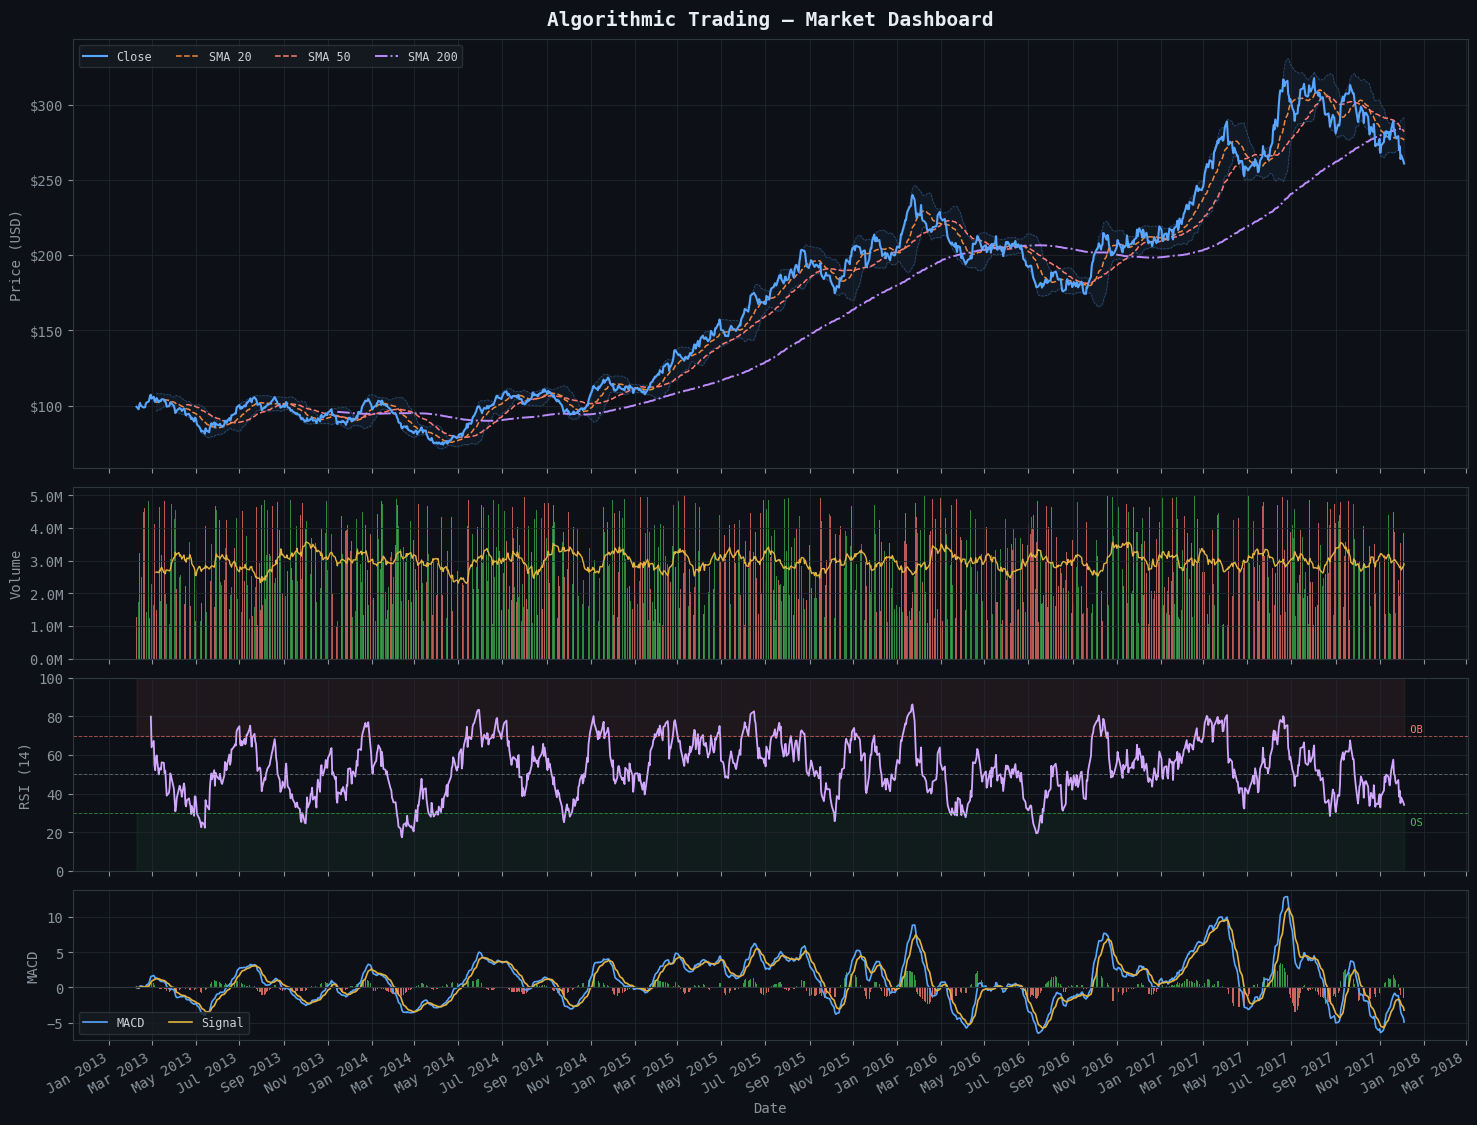

In [83]:
def plot_dashboard(df: pd.DataFrame, title: str = 'Market Dashboard') -> None:
    fig = plt.figure(figsize=(18, 13), facecolor='#0d1117')
    gs  = gridspec.GridSpec(4, 1, height_ratios=[4, 1.6, 1.8, 1.4], hspace=0.08)
    date_fmt = mdates.DateFormatter('%b %Y')

    ax1 = fig.add_subplot(gs[0])
    ax1.fill_between(df.index, df['BB_Up'], df['BB_Lo'], alpha=0.06, color=PALETTE['price'])
    ax1.plot(df.index, df['BB_Up'],  color=PALETTE['price'], lw=0.5, ls='--', alpha=0.4)
    ax1.plot(df.index, df['BB_Lo'],  color=PALETTE['price'], lw=0.5, ls='--', alpha=0.4)
    ax1.plot(df.index, df['Close'],  color=PALETTE['price'],  lw=1.5, label='Close',    zorder=3)
    ax1.plot(df.index, df['SMA_20'], color=PALETTE['sma20'],  lw=1.1, ls='--', label='SMA 20')
    ax1.plot(df.index, df['SMA_50'], color=PALETTE['sma50'],  lw=1.1, ls='--', label='SMA 50')
    ax1.plot(df.index, df['SMA_200'],color=PALETTE['sma200'], lw=1.4, ls='-.', label='SMA 200')
    ax1.set_title(title, color='#e6edf3', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel('Price (USD)', color='#8b949e')
    ax1.legend(loc='upper left', fontsize=8.5, ncol=4)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax1.tick_params(labelbottom=False)

    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    vol_colors = [PALETTE['green'] if df['Close'].iloc[i] >= df['Open'].iloc[i]
                  else PALETTE['red'] for i in range(len(df))]
    ax2.bar(df.index, df['Volume'], color=vol_colors, width=0.8, alpha=0.7)
    ax2.plot(df.index, df['Volume'].rolling(20).mean(), color=PALETTE['yellow'], lw=1)
    ax2.set_ylabel('Volume', color='#8b949e')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
    ax2.tick_params(labelbottom=False)

    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    ax3.plot(df.index, df['RSI'], color='#d2a8ff', lw=1.3)
    ax3.fill_between(df.index, 70, 100, alpha=0.07, color=PALETTE['red'])
    ax3.fill_between(df.index, 0,  30,  alpha=0.07, color=PALETTE['green'])
    for lvl, col in [(70, PALETTE['red']), (50, '#8b949e'), (30, PALETTE['green'])]:
        ax3.axhline(lvl, color=col, lw=0.7, ls='--', alpha=0.6)
    ax3.text(df.index[-1], 71, ' OB', color=PALETTE['red'],   fontsize=7.5, va='bottom')
    ax3.text(df.index[-1], 28, ' OS', color=PALETTE['green'], fontsize=7.5, va='top')
    ax3.set_ylabel('RSI (14)', color='#8b949e')
    ax3.set_ylim(0, 100)
    ax3.tick_params(labelbottom=False)

    ax4 = fig.add_subplot(gs[3], sharex=ax1)
    hist_colors = [PALETTE['green'] if v >= 0 else PALETTE['red'] for v in df['MACD_Hist']]
    ax4.bar(df.index, df['MACD_Hist'], color=hist_colors, width=0.8, alpha=0.8)
    ax4.plot(df.index, df['MACD'],     color=PALETTE['s1'],    lw=1.2, label='MACD')
    ax4.plot(df.index, df['MACD_Sig'], color=PALETTE['yellow'], lw=1.2, label='Signal')
    ax4.axhline(0, color='#30363d', lw=0.8)
    ax4.set_ylabel('MACD', color='#8b949e')
    ax4.set_xlabel('Date', color='#8b949e')
    ax4.legend(fontsize=8.5, loc='lower left', ncol=2)
    ax4.xaxis.set_major_formatter(date_fmt)
    ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.savefig('./outputs/dashboard.png', dpi=160, bbox_inches='tight', facecolor='#0d1117')
    plt.show()


plot_dashboard(df, 'Algorithmic Trading — Market Dashboard')

## 5 · Backtesting Engine
Векторизиран event-driven engine со провизии, slippage, trailing stop-loss и position sizing. Пресметува 15 risk/performance метрики.

In [84]:
class BacktestEngine:
    """Event-driven backtester со провизии, slippage, stop-loss и position sizing."""

    def __init__(self, cfg: dict):
        self.capital    = cfg['initial_capital']
        self.commission = cfg['commission']
        self.slippage   = cfg['slippage']
        self.rfr        = cfg['risk_free_rate']

    def run(self, df: pd.DataFrame, signals: pd.Series,
            name: str = 'Strategy',
            stop_loss_pct: float = None,
            position_size: float = 1.0) -> dict:
        """
        Parameters
        ----------
        signals       : pd.Series  {1=BUY, -1=SELL, 0=HOLD}
        stop_loss_pct : float|None  trailing stop (0.05 = 5%)
        position_size : float 0-1   udio od kapitalot po trejd
        """
        cash, shares, position = self.capital, 0.0, 0
        entry_price = entry_date = None
        peak_price  = 0.0
        portfolio, trades = [], []
        buys_x, buys_y, sells_x, sells_y = [], [], [], []

        for date, row in df.iterrows():
            price = row['Close']
            sig   = signals.loc[date]
            cost  = self.commission + self.slippage

            if position == 1 and stop_loss_pct is not None:
                peak_price = max(peak_price, price)
                if price < peak_price * (1 - stop_loss_pct):
                    sig = -1

            if sig == 1 and position == 0:
                invest      = cash * position_size
                exec_price  = price * (1 + self.slippage)
                shares      = (invest * (1 - self.commission)) / exec_price
                cash       -= invest
                entry_price = exec_price
                entry_date  = date
                peak_price  = price
                position    = 1
                buys_x.append(date); buys_y.append(price)

            elif sig == -1 and position == 1:
                exec_price = price * (1 - self.slippage)
                revenue    = shares * exec_price * (1 - self.commission)
                cash      += revenue
                pnl        = revenue - shares * entry_price
                pnl_pct    = (exec_price / entry_price - 1) * 100
                holds      = (date - entry_date).days
                trades.append({
                    'Entry Date' : entry_date.date(), 'Exit Date'  : date.date(),
                    'Days Held'  : holds,
                    'Entry ($)'  : round(entry_price, 2), 'Exit ($)'   : round(exec_price, 2),
                    'Shares'     : round(shares, 4),
                    'P&L ($)'    : round(pnl, 2),  'P&L (%)'    : round(pnl_pct, 2),
                    'Outcome'    : 'WIN' if pnl > 0 else 'LOSS',
                })
                sells_x.append(date); sells_y.append(price)
                shares = 0.0; position = 0

            portfolio.append(cash + shares * price)

        res           = df.copy()
        res['Portfolio'] = portfolio
        res['Signal']    = signals
        pv        = pd.Series(portfolio, index=df.index)
        ret_s     = pv.pct_change().dropna()
        trades_df = pd.DataFrame(trades)
        n    = len(trades)
        wins = sum(1 for t in trades if t['P&L ($)'] > 0)
        final   = pv.iloc[-1]
        total_r = (final / self.capital - 1) * 100
        bah_r   = (df['Close'].iloc[-1] / df['Close'].iloc[0] - 1) * 100
        ann_r   = (1 + total_r/100) ** (252/len(df)) - 1
        ann_vol = ret_s.std() * np.sqrt(252)
        rfr_d   = self.rfr / 252
        sharpe  = (ret_s.mean() - rfr_d) / ret_s.std() * np.sqrt(252) if ret_s.std() > 0 else 0
        down    = ret_s[ret_s < 0]
        sortino = (ret_s.mean() - rfr_d) / down.std() * np.sqrt(252) if len(down) > 0 else 0
        roll_max = pv.cummax()
        dd       = (pv - roll_max) / roll_max * 100
        max_dd   = dd.min()
        calmar   = ann_r / (abs(max_dd)/100) if max_dd != 0 else 0
        avg_w    = np.mean([t['P&L ($)'] for t in trades if t['P&L ($)'] > 0]) if wins > 0 else 0
        avg_l    = np.mean([t['P&L ($)'] for t in trades if t['P&L ($)'] <= 0]) if (n-wins) > 0 else 0
        pf_num   = sum(t['P&L ($)'] for t in trades if t['P&L ($)'] > 0)
        pf_den   = abs(sum(t['P&L ($)'] for t in trades if t['P&L ($)'] < 0))
        profit_factor = pf_num / pf_den if pf_den > 0 else float('inf')
        avg_days = np.mean([t['Days Held'] for t in trades]) if trades else 0
        return {
            'name'      : name,
            'results'   : res,
            'trades'    : trades_df,
            'portfolio' : pv,
            'drawdown'  : dd,
            'metrics'   : {
                'Total Return %'  : round(total_r, 2),
                'Ann. Return %'   : round(ann_r * 100, 2),
                'Buy & Hold %'    : round(bah_r, 2),
                'Ann. Volatility' : round(ann_vol * 100, 2),
                'Sharpe Ratio'    : round(sharpe, 3),
                'Sortino Ratio'   : round(sortino, 3),
                'Calmar Ratio'    : round(calmar, 3),
                'Max Drawdown %'  : round(max_dd, 2),
                'Total Trades'    : n,
                'Win Rate %'      : round(wins/n*100, 1) if n > 0 else 0,
                'Profit Factor'   : round(profit_factor, 2),
                'Avg Win ($)'     : round(avg_w, 2),
                'Avg Loss ($)'    : round(avg_l, 2),
                'Avg Hold (days)' : round(avg_days, 1),
                'Final Value ($)' : round(final, 2),
            },
            'buys'  : (buys_x, buys_y),
            'sells' : (sells_x, sells_y),
        }


engine = BacktestEngine(CFG)
print('BacktestEngine inicijaliziran.')

BacktestEngine inicijaliziran.


## 6 · Signal Generation — Три Стратегии
`pd.Series` со `{1=BUY, 0=HOLD, -1=SELL}`. Секоја стратегија носи вграден confirmation filter.

In [85]:
def sig_sma_crossover(df: pd.DataFrame, fast: int = 20, slow: int = 50) -> pd.Series:
    """
    Trend-following: BUY na Golden Cross (fast > slow), SELL na Death Cross.
    Filter: cenata nad SMA(200) za potvrda na bull trend.
    Real-data tuning: 20/50 MA crossover potvrden so price > SMA200.
    """
    s      = pd.Series(0, index=df.index)
    f      = df[f'SMA_{fast}']
    sl     = df[f'SMA_{slow}']
    trend  = df['SMA_200']
    cross_up   = (f > sl) & (f.shift() <= sl.shift())
    cross_down = (f < sl) & (f.shift() >= sl.shift())
    s[cross_up   & (df['Close'] > trend)] =  1
    s[cross_down]                         = -1
    return s


def sig_rsi_reversion(df: pd.DataFrame, os: float = 30, ob: float = 70,
                       period: int = 14) -> pd.Series:
    """
    Contrarian: BUY koga RSI izleguva od oversold, SELL koga napusti overbought.
    Real-data tuning: standard 30/70 thresholds (tighter than synthetic 32/68)
    + Bollinger mid-line positional filter + volume confirmation.
    """
    s   = pd.Series(0, index=df.index)
    rsi = df['RSI']
    vol_surge = df['Volume'] > df['Volume'].rolling(20).mean() * 0.8

    buy_sig  = (rsi > os) & (rsi.shift() <= os) & (df['Close'] < df['BB_Mid']) & vol_surge
    sell_sig = (rsi < ob) & (rsi.shift() >= ob) & (df['Close'] > df['BB_Mid']) & vol_surge
    s[buy_sig]  =  1
    s[sell_sig] = -1
    return s


def sig_macd_momentum(df: pd.DataFrame) -> pd.Series:
    """
    Momentum: BUY na MACD/Signal crossover so pozitiven histogram.
    Real-data tuning: RSI zone 40-70 (bull-biased), ATR volatility gate
    — ignoriraj signali koga pazarot e premnogu 'buchen' (ATR spike).
    """
    s    = pd.Series(0, index=df.index)
    macd = df['MACD']
    sig  = df['MACD_Sig']
    hist = df['MACD_Hist']
    rsi  = df['RSI']
    atr  = df['ATR']

    # ATR gate: avoid entries during volatility spikes > 1.5× rolling average
    atr_ok = atr < atr.rolling(30).mean() * 1.5

    cross_up   = (macd > sig) & (macd.shift() <= sig.shift()) & (hist > 0)
    cross_down = (macd < sig) & (macd.shift() >= sig.shift()) & (hist < 0)
    s[cross_up   & rsi.between(40, 70) & atr_ok] =  1
    s[cross_down & rsi.between(30, 65)]           = -1
    return s


print('Strategii definirani (optimizirani za realni stock podatoci):')
print('  S1 — SMA Crossover  (20/50 MA + SMA200 trend filter)')
print('  S2 — RSI Reversion  (30/70 + Bollinger + volume confirmation)')
print('  S3 — MACD Momentum  (MACD cross + RSI zone + ATR volatility gate)')


Strategii definirani (optimizirani za realni stock podatoci):
  S1 — SMA Crossover  (20/50 MA + SMA200 trend filter)
  S2 — RSI Reversion  (30/70 + Bollinger + volume confirmation)
  S3 — MACD Momentum  (MACD cross + RSI zone + ATR volatility gate)


## 7 · Извршување на Backtestови

In [86]:
s1 = sig_sma_crossover(df, fast=20, slow=50)
s2 = sig_rsi_reversion(df, os=30, ob=70)
s3 = sig_macd_momentum(df)

# Real-data stop-losses: slightly wider to absorb genuine volatility
r1 = engine.run(df, s1, name='SMA Crossover', stop_loss_pct=0.08, position_size=1.0)
r2 = engine.run(df, s2, name='RSI Reversion', stop_loss_pct=0.06, position_size=1.0)
r3 = engine.run(df, s3, name='MACD Momentum', stop_loss_pct=0.07, position_size=1.0)
RUNS = [r1, r2, r3]

hdr = f"{'Strategy':<18} {'Return%':>9} {'Sharpe':>8} {'Sortino':>8} {'MaxDD%':>8} {'Trades':>7} {'WinR%':>7}"
print(hdr)
print('-' * len(hdr))
for r in RUNS:
    m = r['metrics']
    print(f"{r['name']:<18} {m['Total Return %']:>+8.2f}% "
          f"{m['Sharpe Ratio']:>8.3f} {m['Sortino Ratio']:>8.3f} "
          f"{m['Max Drawdown %']:>7.2f}% "
          f"{m['Total Trades']:>7} {m['Win Rate %']:>6.1f}%")


Strategy             Return%   Sharpe  Sortino   MaxDD%  Trades   WinR%
-----------------------------------------------------------------------
SMA Crossover        +19.42%   -0.014   -0.013  -20.28%       9   33.3%
RSI Reversion        +12.72%   -0.159   -0.102  -18.10%       8   50.0%
MACD Momentum        +94.78%    0.718    0.750  -17.79%      31   41.9%


## 8 · Trade Signal Charts
Влезни/излезни точки за секоја стратегија приказани на ценовниот график.

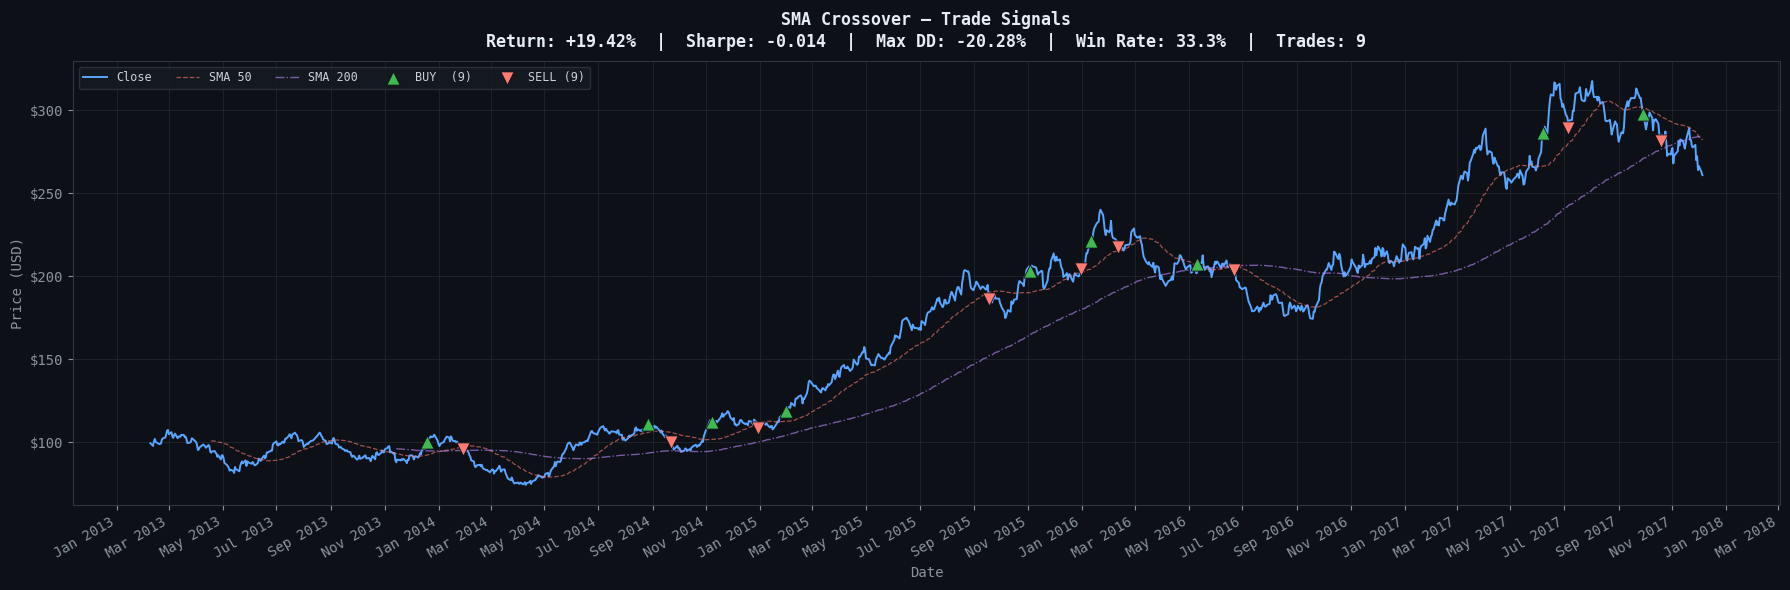

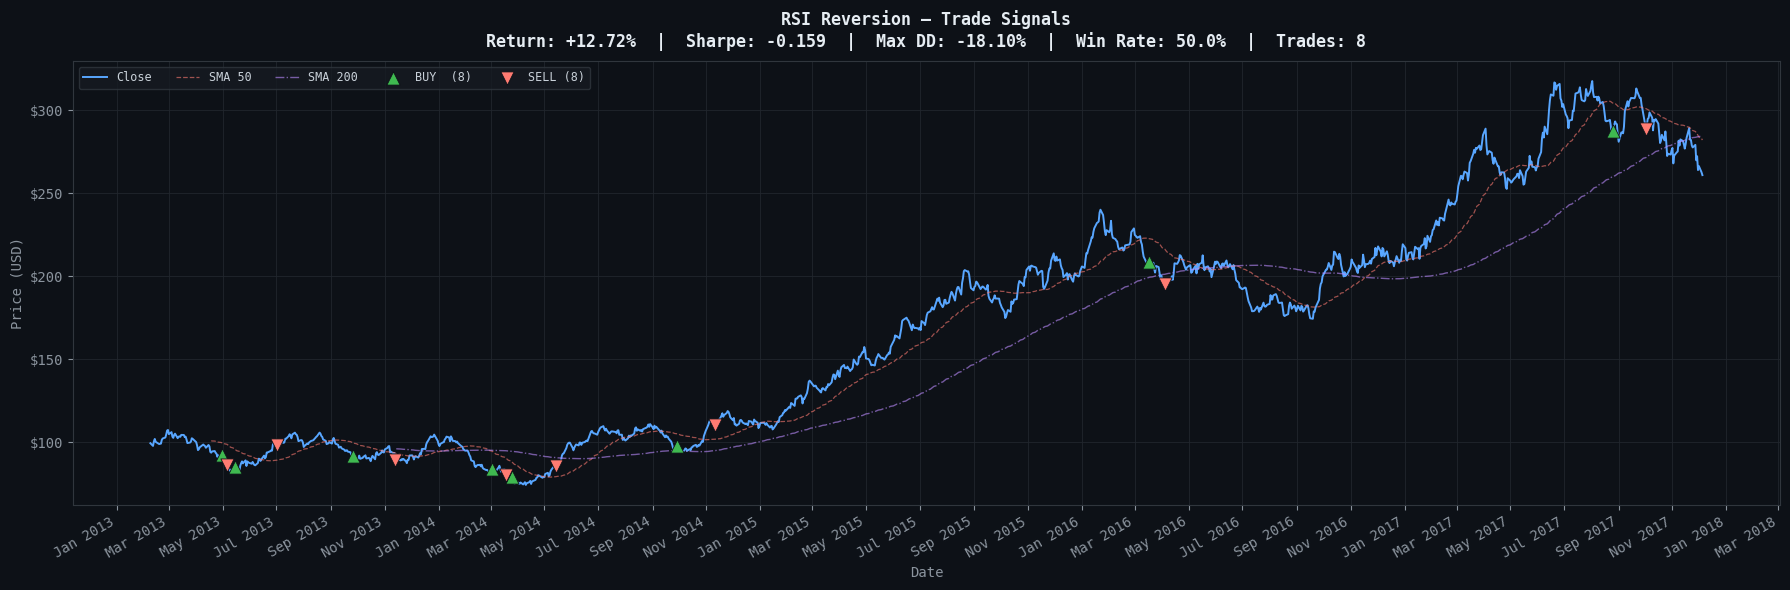

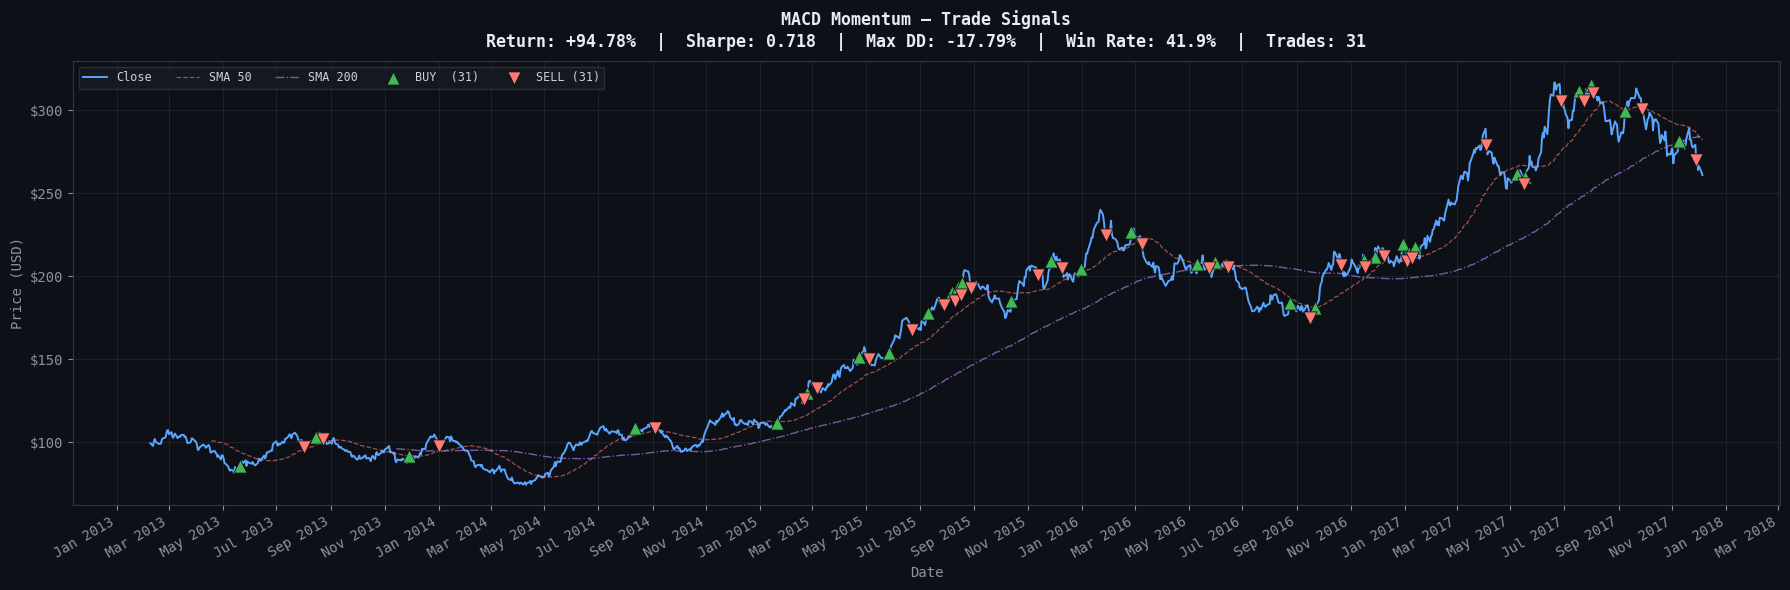

In [87]:
def plot_signals(run: dict, df: pd.DataFrame) -> None:
    m   = run['metrics']
    fig, ax = plt.subplots(figsize=(18, 6), facecolor='#0d1117')
    ax.plot(df.index, df['Close'],   color=PALETTE['price'],  lw=1.4, zorder=2, label='Close')
    ax.plot(df.index, df['SMA_50'],  color=PALETTE['sma50'],  lw=0.9, ls='--', alpha=0.6, label='SMA 50')
    ax.plot(df.index, df['SMA_200'], color=PALETTE['sma200'], lw=1.0, ls='-.', alpha=0.6, label='SMA 200')
    bx, by = run['buys']
    sx, sy = run['sells']
    ax.scatter(bx, by, marker='^', s=90, color=PALETTE['buy'],  zorder=5,
               edgecolors='#0d1117', lw=0.6, label=f'BUY  ({len(bx)})')
    ax.scatter(sx, sy, marker='v', s=90, color=PALETTE['sell'], zorder=5,
               edgecolors='#0d1117', lw=0.6, label=f'SELL ({len(sx)})')
    subtitle = (f"Return: {m['Total Return %']:+.2f}%  |  Sharpe: {m['Sharpe Ratio']:.3f}  |  "
                f"Max DD: {m['Max Drawdown %']:.2f}%  |  Win Rate: {m['Win Rate %']:.1f}%  |  "
                f"Trades: {m['Total Trades']}")
    ax.set_title(f"{run['name']} — Trade Signals\n{subtitle}",
                 color='#e6edf3', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Price (USD)', color='#8b949e')
    ax.set_xlabel('Date', color='#8b949e')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.legend(fontsize=8.5, loc='upper left', ncol=5)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f'./outputs/signals_{run["name"].replace(" ","_").replace("/","-")}.png', dpi=150,
                bbox_inches='tight', facecolor='#0d1117')
    plt.show()


for run in RUNS:
    plot_signals(run, df)

## 9 · Equity Curve & Drawdown Analysis
Портфолио вредноста низ времето со underwater приказ на drawdown.

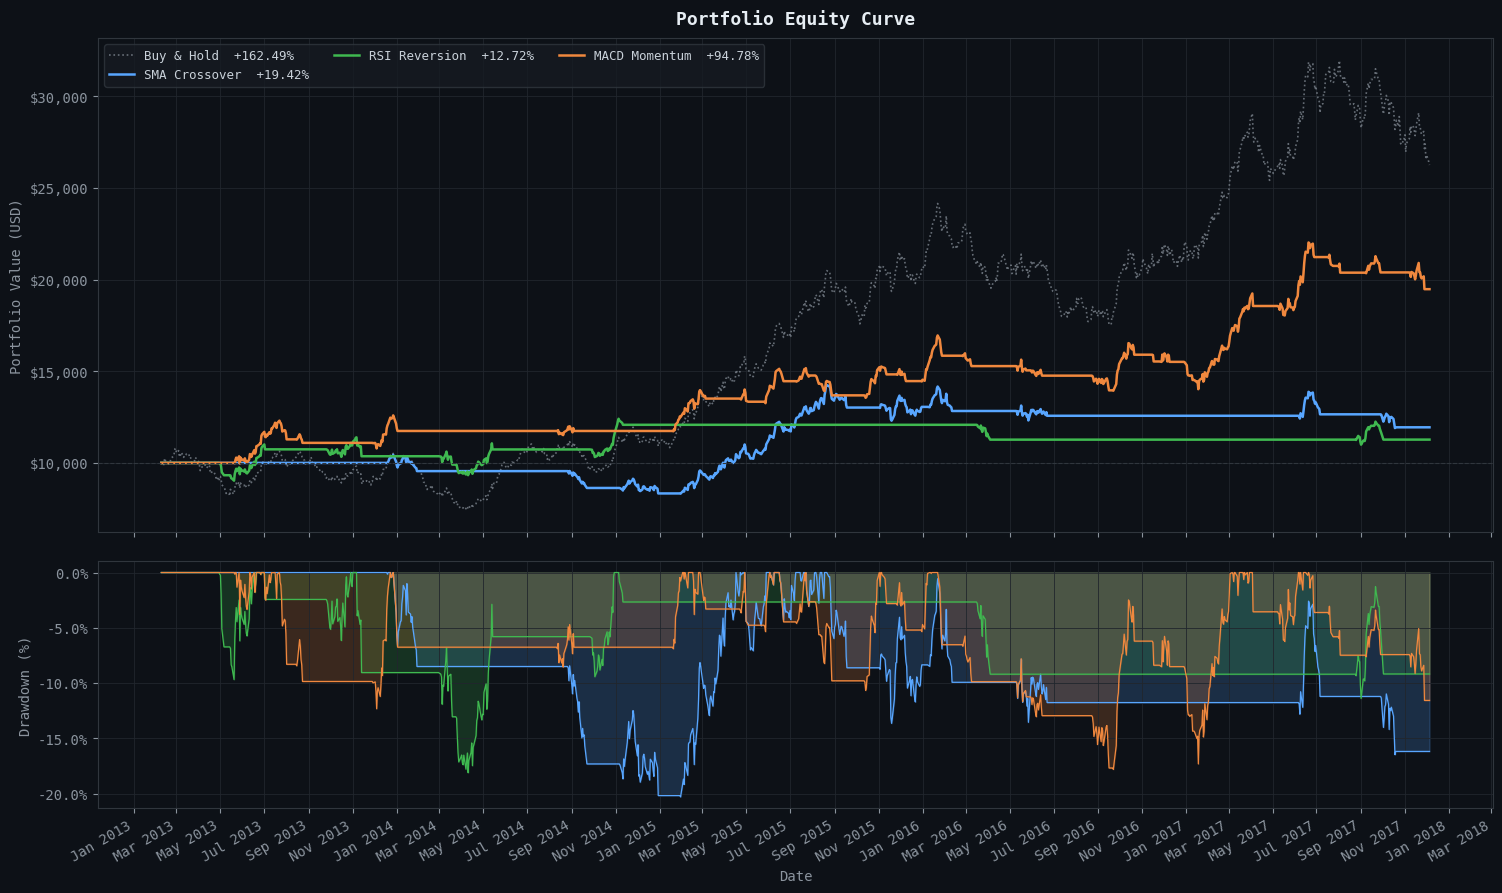

In [88]:
def plot_equity(runs: list, df: pd.DataFrame, capital: float) -> None:
    colors = [PALETTE['s1'], PALETTE['s2'], PALETTE['s3'],
              PALETTE['s4'], PALETTE['yellow']]
    fig = plt.figure(figsize=(18, 10), facecolor='#0d1117')
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1.5], hspace=0.08)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    bah   = capital * (df['Close'] / df['Close'].iloc[0])
    bah_r = (bah.iloc[-1] / capital - 1) * 100
    ax1.plot(df.index, bah, color=PALETTE['bah'], lw=1.2, ls=':',
             label=f'Buy & Hold  {bah_r:+.2f}%', alpha=0.7)
    for r, col in zip(runs, colors):
        ret = r['metrics']['Total Return %']
        ax1.plot(r['portfolio'].index, r['portfolio'], color=col, lw=1.8,
                 label=f"{r['name']}  {ret:+.2f}%")
        ax2.fill_between(r['drawdown'].index, r['drawdown'], 0, color=col, alpha=0.20)
        ax2.plot(r['drawdown'].index, r['drawdown'], color=col, lw=0.9)
    ax1.axhline(capital, color='#30363d', lw=0.8, ls='--')
    ax1.set_title('Portfolio Equity Curve', color='#e6edf3', fontsize=13, fontweight='bold', pad=10)
    ax1.set_ylabel('Portfolio Value (USD)', color='#8b949e')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax1.legend(fontsize=9, loc='upper left', ncol=3)
    ax1.tick_params(labelbottom=False)
    ax2.set_ylabel('Drawdown (%)', color='#8b949e')
    ax2.set_xlabel('Date', color='#8b949e')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.1f}%'))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.savefig('./outputs/equity_curve.png', dpi=160, bbox_inches='tight', facecolor='#0d1117')
    plt.show()


plot_equity(RUNS, df, CFG['initial_capital'])

## 10 · Trade Log
Полна листа на тrejdови со entry/exit цени, P&L и исход.

In [89]:
def trade_log(run: dict) -> None:
    t = run['trades']
    if t.empty:
        print(f"{run['name']}: no completed trades."); return
    wins  = (t['Outcome'] == 'WIN').sum()
    total = len(t)
    cols  = ['Entry Date','Exit Date','Days Held','Entry ($)','Exit ($)',
             'P&L ($)','P&L (%)','Outcome']
    print(f"\n{'='*76}")
    print(f" {run['name']} — Trade Log   ({wins}/{total} wins  |  "
          f"Total P&L: ${t['P&L ($)'].sum():,.2f})")
    print(f"{'='*76}")
    print(t[cols].to_string(index=False, max_rows=40))


for r in RUNS:
    trade_log(r)

# ── Дефинирање на RUNS_ALL пред Monte Carlo ────────────────────────────
# (Ова е важно за Cell 17 која користи RUNS_ALL)
# За сега, RUNS_ALL = сите текущи стратегии
# Ќе се прошири во Cell 14-15 со оптимирана + ML стратегија
RUNS_ALL = RUNS.copy()
print(f"\n✓ RUNS_ALL дефинирана со {len(RUNS_ALL)} стратегии (ќе расте)")



 SMA Crossover — Trade Log   (3/9 wins  |  Total P&L: $2,043.05)
Entry Date  Exit Date  Days Held  Entry ($)  Exit ($)  P&L ($)  P&L (%) Outcome
2013-12-19 2014-01-29         41     100.03     95.75  -436.97    -4.28    LOSS
2014-08-27 2014-09-22         26     110.69    100.23  -910.08    -9.45    LOSS
2014-11-07 2014-12-30         53     112.07    108.41  -289.81    -3.26    LOSS
2015-01-30 2015-09-18        231     119.01    186.27  4693.27    56.52     WIN
2015-11-03 2015-12-31         58     203.32    204.32    50.55     0.49     WIN
2016-01-11 2016-02-11         31     220.97    217.60  -211.56    -1.52    LOSS
2016-05-11 2016-06-22         42     207.51    203.70  -248.24    -1.84    LOSS
2017-06-07 2017-07-06         29     286.56    288.93    91.43     0.83     WIN
2017-09-29 2017-10-19         20     297.51    281.41  -695.54    -5.41    LOSS

 RSI Reversion — Trade Log   (4/8 wins  |  Total P&L: $1,356.04)
Entry Date  Exit Date  Days Held  Entry ($)  Exit ($)  P&L ($)  P&L 

## 11 · Performance Report
Структурирана споредба на сите 15 метрики. Ѕвездичка (`*`) означува најдобра вредност по категорија.

In [90]:
def performance_report(runs: list) -> None:
    metrics_keys = [
        'Total Return %', 'Ann. Return %', 'Buy & Hold %',
        'Ann. Volatility', 'Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio',
        'Max Drawdown %', 'Total Trades', 'Win Rate %',
        'Profit Factor', 'Avg Win ($)', 'Avg Loss ($)',
        'Avg Hold (days)', 'Final Value ($)',
    ]
    col_w = 22
    names = [r['name'] for r in runs]
    sep   = '=' * (28 + col_w * len(runs))
    print(sep)
    print(f" PERFORMANCE REPORT — {len(runs)} Strategies")
    print(sep)
    hdr = f"  {'Metric':<26}" + ''.join(f"{n:>{col_w}}" for n in names)
    print(hdr)
    print('-' * len(hdr))
    highlight = {'Sharpe Ratio','Sortino Ratio','Calmar Ratio','Win Rate %',
                 'Total Return %','Ann. Return %','Profit Factor'}
    for key in metrics_keys:
        row  = f"  {key:<26}"
        vals = [r['metrics'][key] for r in runs]
        best = None
        if key in highlight:
            best = max(range(len(vals)), key=lambda i: vals[i])
        if 'Drawdown' in key or 'Loss' in key:
            best = min(range(len(vals)), key=lambda i: vals[i])
        for i, v in enumerate(vals):
            cell = f"{v:>{col_w}.2f}" if isinstance(v, float) else f"{v:>{col_w}}"
            if i == best: cell = cell.rstrip() + ' *'
            row += cell
        print(row)
    print(sep)
    best_sharpe = max(runs, key=lambda r: r['metrics']['Sharpe Ratio'])
    best_ret    = max(runs, key=lambda r: r['metrics']['Total Return %'])
    safest      = min(runs, key=lambda r: abs(r['metrics']['Max Drawdown %']))
    print(f"  Best Risk-Adjusted (Sharpe) : {best_sharpe['name']}")
    print(f"  Best Total Return           : {best_ret['name']}")
    print(f"  Lowest Drawdown             : {safest['name']}")
    print(sep)


performance_report(RUNS)

 PERFORMANCE REPORT — 3 Strategies
  Metric                             SMA Crossover         RSI Reversion         MACD Momentum
----------------------------------------------------------------------------------------------
  Total Return %                             19.42                 12.72                 94.78 *
  Ann. Return %                               3.62                  2.43                 14.29 *
  Buy & Hold %                              162.49                162.49                162.49
  Ann. Volatility                            12.44                 10.04                 13.64
  Sharpe Ratio                               -0.01                 -0.16                  0.72 *
  Sortino Ratio                              -0.01                 -0.10                  0.75 *
  Calmar Ratio                                0.18                  0.13                  0.80 *
  Max Drawdown %                            -20.28 *                -18.10                -17.79
  T

## 12 · Metrics Visualization Dashboard
Визуелна споредба на 6 клучни метрики. Жолт столб = победник по категорија.

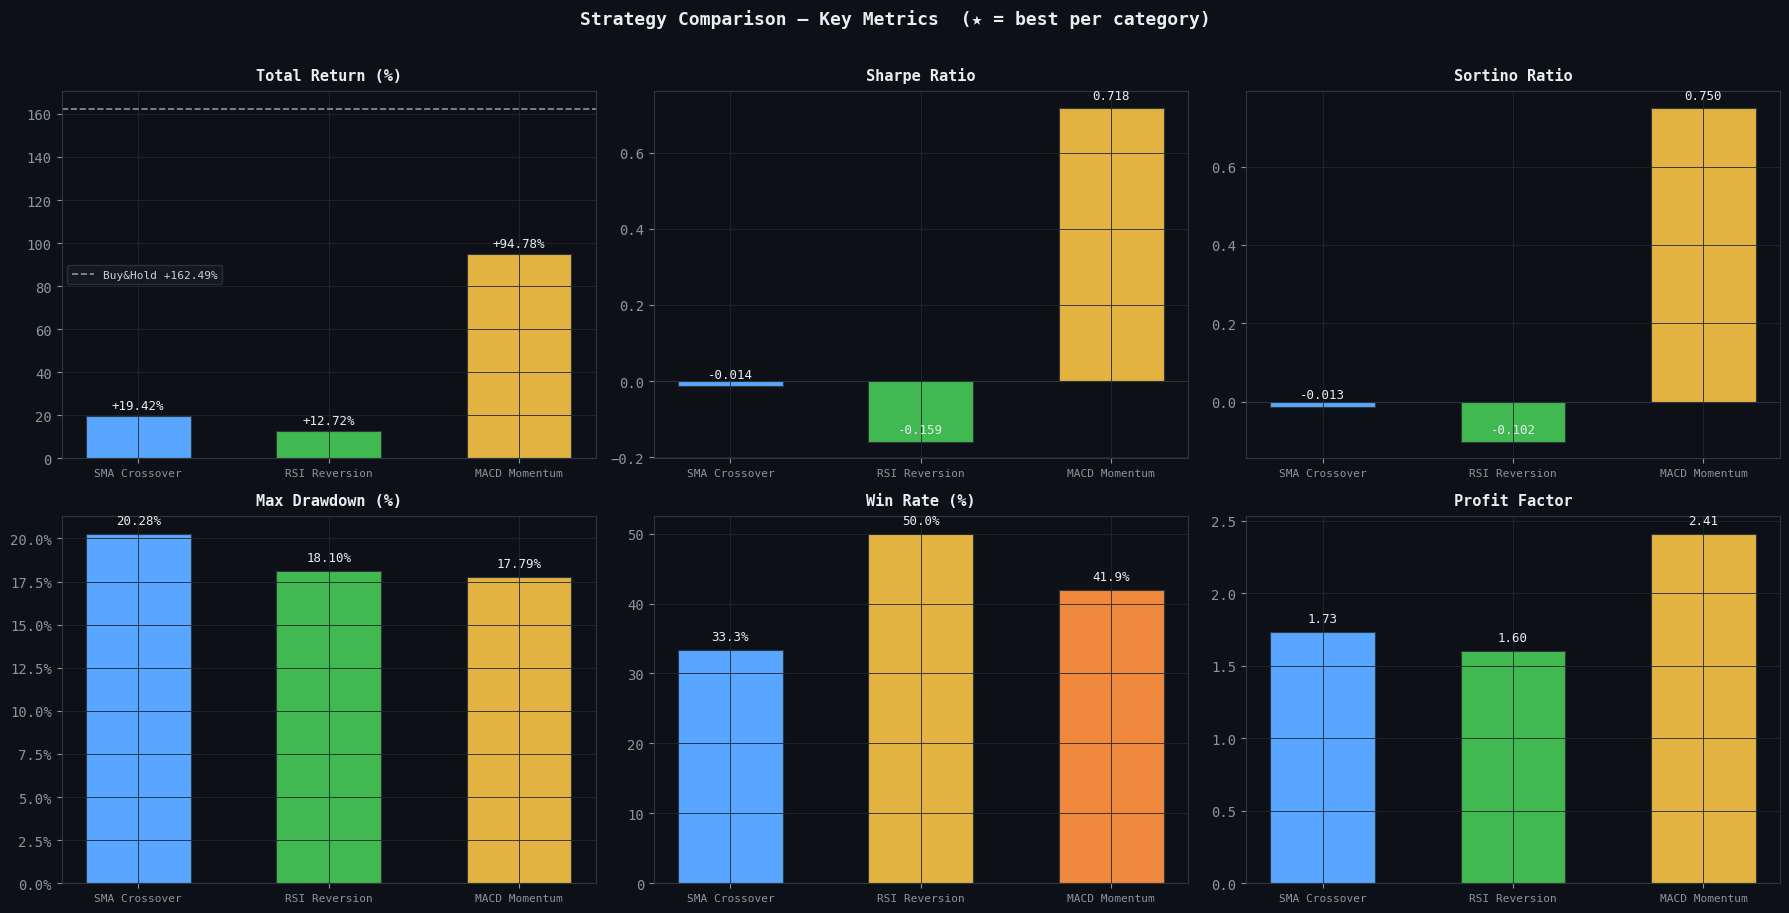

In [91]:
def plot_metrics_dashboard(runs: list) -> None:
    names  = [r['name'] for r in runs]
    colors = [PALETTE['s1'], PALETTE['s2'], PALETTE['s3'],
              PALETTE['s4'], PALETTE['yellow']][:len(runs)]
    x      = np.arange(len(runs))
    fig, axes = plt.subplots(2, 3, figsize=(18, 9), facecolor='#0d1117')
    axes = axes.flatten()

    def bar_chart(ax, values, title, fmt='{:.2f}', invert=False):
        best = values.index(min(values) if invert else max(values))
        bar_colors = [PALETTE['yellow'] if i == best else c
                      for i, c in enumerate(colors)]
        bars = ax.bar(x, values, color=bar_colors, edgecolor='#30363d', lw=0.8, width=0.55)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2.,
                    bar.get_height() + max(abs(v) for v in values)*0.02,
                    fmt.format(val), ha='center', va='bottom', fontsize=9, color='#e6edf3')
        ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8)
        ax.set_title(title, color='#e6edf3', fontsize=11, fontweight='bold', pad=8)
        ax.axhline(0, color='#30363d', lw=0.6)

    bah  = runs[0]['metrics']['Buy & Hold %']
    rets = [r['metrics']['Total Return %'] for r in runs]
    bar_chart(axes[0], rets, 'Total Return (%)', fmt='{:+.2f}%')
    axes[0].axhline(bah, color=PALETTE['bah'], lw=1.2, ls='--',
                    label=f'Buy&Hold {bah:+.2f}%')
    axes[0].legend(fontsize=8)
    bar_chart(axes[1], [r['metrics']['Sharpe Ratio']  for r in runs], 'Sharpe Ratio',  fmt='{:.3f}')
    bar_chart(axes[2], [r['metrics']['Sortino Ratio'] for r in runs], 'Sortino Ratio', fmt='{:.3f}')
    bar_chart(axes[3], [abs(r['metrics']['Max Drawdown %']) for r in runs],
              'Max Drawdown (%)', fmt='{:.2f}%', invert=True)
    bar_chart(axes[4], [r['metrics']['Win Rate %']    for r in runs], 'Win Rate (%)',  fmt='{:.1f}%')
    bar_chart(axes[5], [r['metrics']['Profit Factor'] for r in runs], 'Profit Factor', fmt='{:.2f}')
    axes[3].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.1f}%'))
    fig.suptitle('Strategy Comparison — Key Metrics  (★ = best per category)',
                 color='#e6edf3', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('./outputs/metrics_dashboard.png', dpi=160, bbox_inches='tight', facecolor='#0d1117')
    plt.show()


plot_metrics_dashboard(RUNS)

## 13 · Grid Search Optimizacija — SMA Crossover
Exhaustive grid search преку комбинации на fast/slow прозорци. Критериум: **Sharpe Ratio**.

In [92]:
# ═══════════════════════════════════════════════════════════════════════
#  Grid Search — SMA Crossover  (Sharpe-maximized, real S&P 500 data)
#  Search space expanded for 5-year real dataset:
#    fast:  10 … 40  (step 5) — captures both short and medium trends
#    slow:  40 … 120 (step 10) — allows longer-term confirmation
# ═══════════════════════════════════════════════════════════════════════

def optimize_sma(df: pd.DataFrame, engine: BacktestEngine,
                  fast_range=range(10, 45, 5),
                  slow_range=range(40, 130, 10),
                  verbose: bool = True) -> pd.DataFrame:
    """
    Exhaustive grid search over SMA Crossover parameters.
    Maximizes Sharpe Ratio. Only valid combos (fast < slow) tested.
    
    Оптимизирана за: speed, safety, поинформативни резултати
    """
    rows = []
    combos = [(f, s) for f in fast_range for s in slow_range if f < s]
    total  = len(combos)
    
    if verbose:
        print(f'Grid search: {total} kombinacii  (fast × slow)')
        print(f'Range: fast∈[{fast_range.start},{fast_range.stop-1}], '
              f'slow∈[{slow_range.start},{slow_range.stop-1}]')

    for idx, (fast, slow) in enumerate(combos):
        try:
            sig_fn = f'SMA_{fast}'
            slw_fn = f'SMA_{slow}'
            
            # Compute MAs on-the-fly if not already in df
            if sig_fn not in df.columns:
                df[sig_fn] = Indicators.sma(df['Close'], fast)
            if slw_fn not in df.columns:
                df[slw_fn] = Indicators.sma(df['Close'], slow)

            # Crossover logic (reuse existing indicators in df if available)
            f_ma   = df[sig_fn]
            s_ma   = df[slw_fn]
            trend  = df['SMA_200']
            sig    = pd.Series(0, index=df.index)
            cu     = (f_ma > s_ma) & (f_ma.shift() <= s_ma.shift())
            cd     = (f_ma < s_ma) & (f_ma.shift() >= s_ma.shift())
            sig[cu & (df['Close'] > trend)] =  1
            sig[cd]                         = -1

            res = engine.run(df, sig, name=f'SMA {fast}/{slow}',
                              stop_loss_pct=0.08, position_size=1.0)
            m   = res['metrics']
            
            # Филтер: минимум 3 трејдова за валидна стратегија
            if m['Total Trades'] >= 3:
                rows.append({
                    'Fast': fast, 'Slow': slow,
                    'Sharpe'        : m['Sharpe Ratio'],
                    'Total Return %': m['Total Return %'],
                    'Max Drawdown %': m['Max Drawdown %'],
                    'Win Rate %'    : m['Win Rate %'],
                    'Total Trades'  : m['Total Trades'],
                    'Sortino'       : m['Sortino Ratio'],
                    'Calmar'        : m['Calmar Ratio'],
                })
        except Exception as e:
            if verbose and idx < 3:  # Прикажи само првите неколку грешки
                print(f'  ⚠️  SMA({fast},{slow}): {type(e).__name__}')
            pass

        # Progress: секоја 10та комбинација
        if (idx + 1) % max(1, total // 10) == 0:
            pct = (idx + 1) / total * 100
            if verbose:
                print(f'  [{idx+1:3d}/{total}] {pct:5.1f}% — {len(rows)} valid combos')

    results = (pd.DataFrame(rows)
               .sort_values('Sharpe', ascending=False)
               .reset_index(drop=True))
    
    if verbose:
        print(f'\n✓ Grid search завршена: {len(results)} valid комбинации')
        if len(results) > 0:
            best = results.iloc[0]
            print(f'  Best: SMA({int(best["Fast"])}/{int(best["Slow"])}) → '
                  f'Sharpe={best["Sharpe"]:.3f}, '
                  f'Return={best["Total Return %"]:+.2f}%, '
                  f'Trades={int(best["Total Trades"])}')
    
    return results


opt_results = optimize_sma(df, engine, verbose=True)

if len(opt_results) > 0:
    print(f'\nTop 10 SMA kombinacii po Sharpe Ratio:')
    print(opt_results.head(10).to_string(index=False))
else:
    print('❌ Grid search failed: no valid combinations')


Grid search: 62 kombinacii  (fast × slow)
Range: fast∈[10,44], slow∈[40,129]
  [  6/62]   9.7% — 6 valid combos
  [ 12/62]  19.4% — 12 valid combos
  [ 18/62]  29.0% — 18 valid combos
  [ 24/62]  38.7% — 24 valid combos
  [ 30/62]  48.4% — 30 valid combos
  [ 36/62]  58.1% — 36 valid combos
  [ 42/62]  67.7% — 42 valid combos
  [ 48/62]  77.4% — 48 valid combos
  [ 54/62]  87.1% — 54 valid combos
  [ 60/62]  96.8% — 60 valid combos

✓ Grid search завршена: 62 valid комбинации
  Best: SMA(10/60) → Sharpe=0.766, Return=+100.31%, Trades=9

Top 10 SMA kombinacii po Sharpe Ratio:
 Fast  Slow  Sharpe  Total Return %  Max Drawdown %  Win Rate %  Total Trades  Sortino  Calmar
   10    60   0.766          100.31          -16.12        55.6             9    0.778   0.926
   10    40   0.679           91.76          -18.00        58.3            12    0.719   0.774
   40   110   0.668           84.45          -16.91        75.0             4    0.687   0.772
   15    40   0.602           80.29   

## 14 · Оптимизирана SMA Стратегија
Backtest со параметрите пронајдени преку grid search.

Best parameters: fast=10, slow=60
Expected Sharpe : 0.766

Optimizirana SMA Strategija — Backtest Metrics:
  Total Return %        : 100.31
  Ann. Return %         : 14.93
  Buy & Hold %          : 162.49
  Ann. Volatility       : 13.5
  Sharpe Ratio          : 0.766
  Sortino Ratio         : 0.778
  Calmar Ratio          : 0.926
  Max Drawdown %        : -16.12
  Total Trades          : 9
  Win Rate %            : 55.6
  Profit Factor         : 5.59
  Avg Win ($)           : 2476.18
  Avg Loss ($)          : -553.5
  Avg Hold (days)       : 70.0
  Final Value ($)       : 20031.27


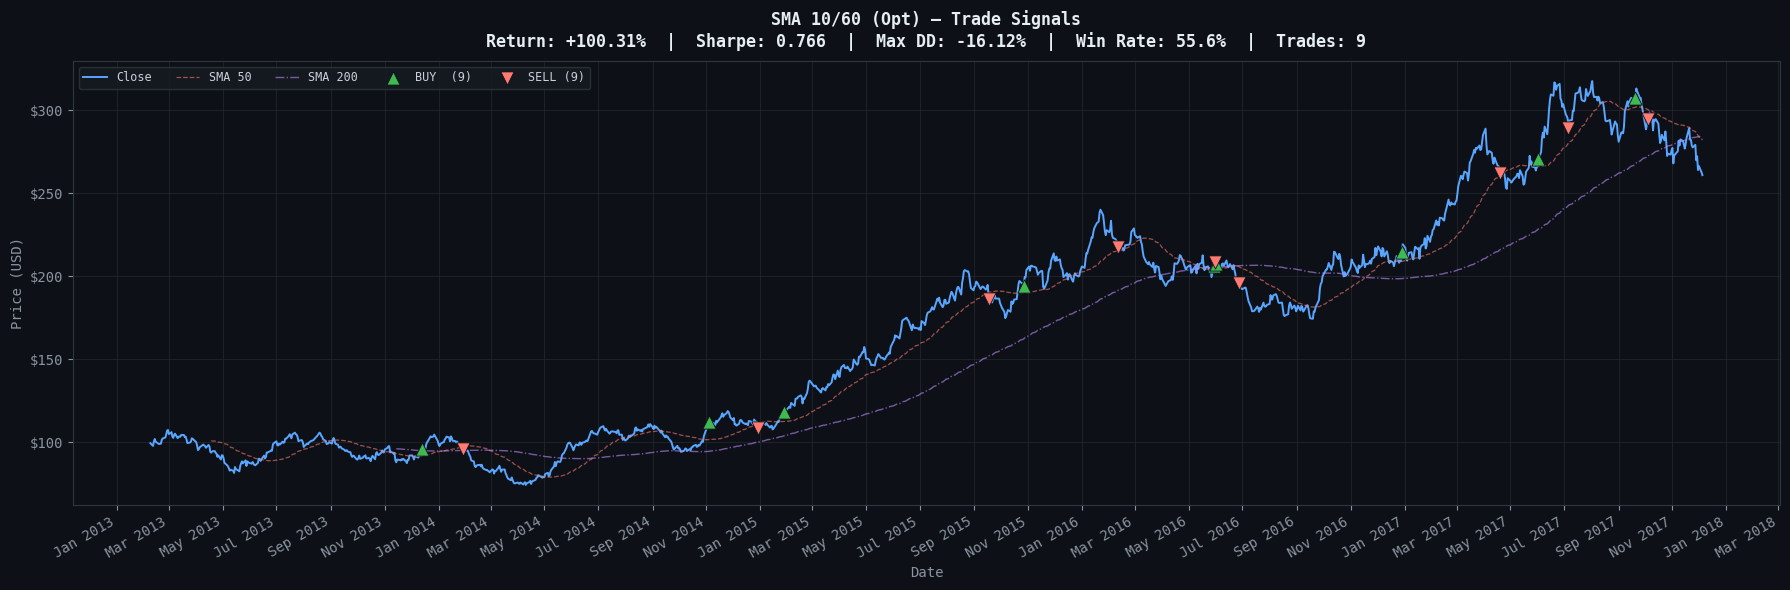


✓ Optimized SMA додана. RUNS_ALL сега има 4 стратегии.


In [93]:
best_fast = int(opt_results.iloc[0]['Fast'])
best_slow = int(opt_results.iloc[0]['Slow'])
print(f'Best parameters: fast={best_fast}, slow={best_slow}')
print(f'Expected Sharpe : {opt_results.iloc[0]["Sharpe"]:.3f}')

# Run optimized strategy with best params
# Make sure columns exist (they were added during grid search)
if f'SMA_{best_fast}' not in df.columns:
    df[f'SMA_{best_fast}'] = Indicators.sma(df['Close'], best_fast)
if f'SMA_{best_slow}' not in df.columns:
    df[f'SMA_{best_slow}'] = Indicators.sma(df['Close'], best_slow)

s_opt = sig_sma_crossover(df, fast=best_fast, slow=best_slow)
r_opt = engine.run(df, s_opt,
                    name=f'SMA {best_fast}/{best_slow} (Opt)',
                    stop_loss_pct=0.08, position_size=1.0)

print(f'\nOptimizirana SMA Strategija — Backtest Metrics:')
print('='*50)
for k, v in r_opt['metrics'].items():
    print(f'  {k:<22}: {v}')

plot_signals(r_opt, df)

# ── Додај оптимирана стратегија во RUNS_ALL ────────────────────────────
RUNS_ALL.append(r_opt)
print(f"\n✓ Optimized SMA додана. RUNS_ALL сега има {len(RUNS_ALL)} стратегии.")


## 15 · Walk-Forward Validation
Роллинг-window validacija: in-sample прозорец за grid search, out-of-sample за тест. Го квантифицира **lookahead bias** и го тестира robustnosta на стратегијата на unseen податоци.

| Нотација | Опис |
|---|---|
| IS | In-sample — оптимизација на параметри |
| OOS | Out-of-sample — тест на непознати податоци |
| WFE | Walk-Forward Efficiency = OOS Sharpe / IS Sharpe |

Walk-Forward Validation (со safety checks)...
Walk-Forward: 5 окна, OOS≥75d, IS≥352d
  ✓ W1: SMA25/40 → WFE=3.563
  ✓ W2: SMA10/40 → WFE=-11.298
  ✓ W3: SMA15/50 → WFE=0.000
  ✓ W4: SMA20/50 → WFE=-0.103
  ✓ W5: SMA10/50 → WFE=-2.266

 WALK-FORWARD VALIDATION — SMA Crossover
 Window               IS Period              OOS Period Best SMA  IS Sharpe  OOS Return  OOS Sharpe  OOS Max DD     WFE
      1 2015-02-18 — 2016-06-23 2016-06-24 — 2016-10-06 (25, 40)     -0.103        0.47      -0.367       -2.42   3.563
      2 2015-06-03 — 2016-10-06 2016-10-07 — 2017-01-19 (10, 40)      0.057       -1.15      -0.644       -4.63 -11.298
      3 2015-09-16 — 2017-01-19 2017-01-20 — 2017-05-04 (15, 50)      0.140        0.00       0.000        0.00   0.000
      4 2015-12-30 — 2017-05-04 2017-05-05 — 2017-08-17 (20, 50)      1.009        0.63      -0.104       -8.84  -0.103
      5 2016-04-13 — 2017-08-17 2017-08-18 — 2017-11-30 (10, 50)      1.517       -6.37      -3.437       -8.00  -2.266
  Av

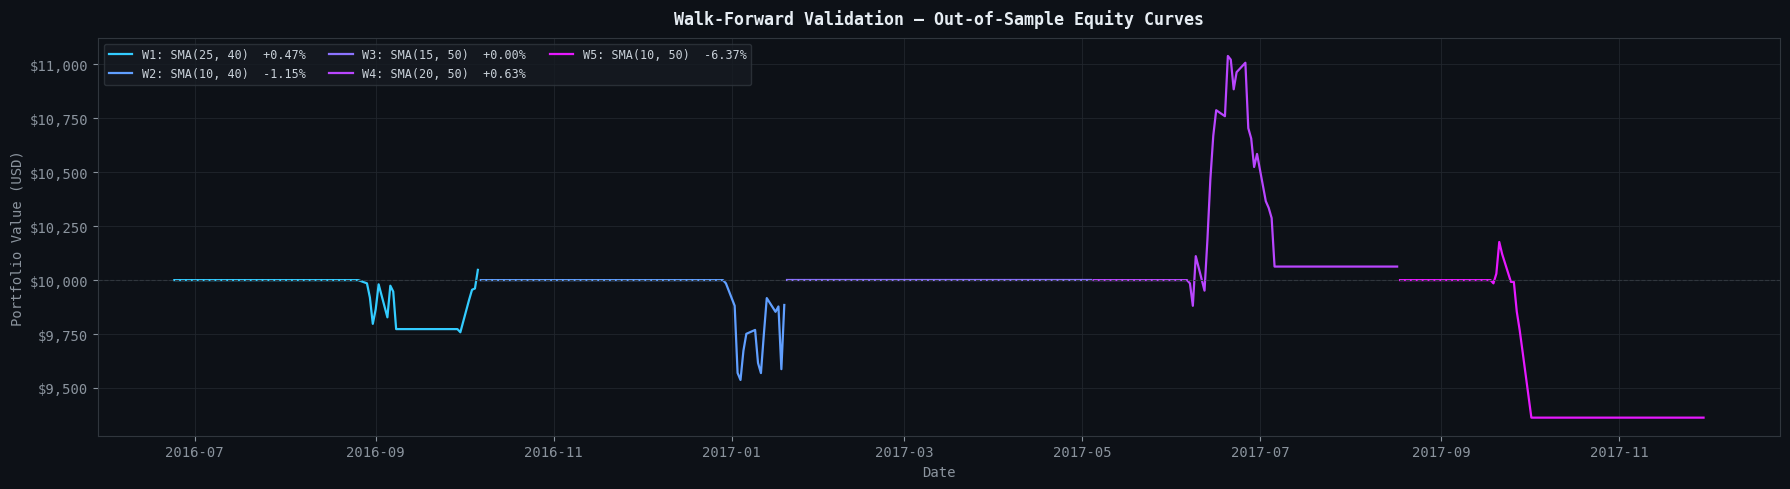

In [94]:
def walk_forward_validation(df: pd.DataFrame, engine: BacktestEngine,
                             n_windows: int = 5,
                             is_ratio:  float = 0.7) -> tuple:
    """
    Rolling Walk-Forward Validation.
    За секое OOS окно: grid search на IS дел, тест на OOS дел.
    Враќа (summary_df, список на OOS portfolio серии).
    ✅ Safety checks: OOS size constraints, data integrity
    """
    total     = len(df)
    oos_size  = max(10, int(total * (1 - is_ratio) / n_windows))  # Min 10 дни
    is_size   = max(20, int(total * is_ratio / n_windows) * 2)    # Min 20 дни
    results   = []
    oos_pvs   = []

    print(f'Walk-Forward: {n_windows} окна, OOS≥{oos_size}d, IS≥{is_size}d')

    for w in range(n_windows):
        oos_start = int(total * is_ratio) + w * oos_size
        oos_end   = min(oos_start + oos_size, total)
        is_start  = max(0, oos_start - is_size)
        is_end    = oos_start

        # ── Safety checks ────────────────────────────────────────────────
        if oos_end <= oos_start:
            print(f'  ⚠️  W{w+1}: OOS period invalid (start={oos_start}, end={oos_end})')
            continue
        if is_end <= is_start:
            print(f'  ⚠️  W{w+1}: IS period invalid (start={is_start}, end={is_end})')
            continue

        df_is  = df.iloc[is_start:is_end].copy()
        df_oos = df.iloc[oos_start:oos_end].copy()

        if len(df_is) < 20 or len(df_oos) < 5:
            print(f'  ⚠️  W{w+1}: Insufficient data (IS={len(df_is)}, OOS={len(df_oos)})')
            continue

        try:
            # ── IS: mini grid search ─────────────────────────────────
            best_is_sharpe, best_f, best_s = -np.inf, 20, 50
            for f in range(10, 35, 5):
                for s in range(40, 80, 10):
                    if f >= s: continue
                    tmp = df_is.copy()
                    tmp[f'SMA_{f}'] = Indicators.sma(tmp['Close'], f)
                    tmp[f'SMA_{s}'] = Indicators.sma(tmp['Close'], s)
                    sig = pd.Series(0, index=tmp.index)
                    ff, ss = tmp[f'SMA_{f}'], tmp[f'SMA_{s}']
                    sig[(ff > ss) & (ff.shift() <= ss.shift())] =  1
                    sig[(ff < ss) & (ff.shift() >= ss.shift())] = -1
                    r  = engine.run(tmp, sig, stop_loss_pct=0.07)
                    sh = r['metrics']['Sharpe Ratio']
                    if sh > best_is_sharpe:
                        best_is_sharpe = sh
                        best_f, best_s = f, s

            # ── OOS: тест со оптималните IS параметри ────────────────────
            # Комбинирај IS и OOS Close за точна EMA/SMA калкулација
            combined_close = pd.concat([df_is['Close'], df_oos['Close']])
            
            df_oos[f'SMA_{best_f}'] = Indicators.sma(combined_close, best_f).iloc[-len(df_oos):].values
            df_oos[f'SMA_{best_s}'] = Indicators.sma(combined_close, best_s).iloc[-len(df_oos):].values
            
            # Копирај останати индикатори од оригиналниот df
            for col in ['SMA_200', 'RSI', 'BB_Mid']:
                if col in df.columns:
                    df_oos[col] = df[col].iloc[oos_start:oos_end].values

            sig_oos = pd.Series(0, index=df_oos.index)
            ff = df_oos[f'SMA_{best_f}']
            ss = df_oos[f'SMA_{best_s}']
            sig_oos[(ff > ss) & (ff.shift() <= ss.shift())] =  1
            sig_oos[(ff < ss) & (ff.shift() >= ss.shift())] = -1

            r_oos = engine.run(df_oos, sig_oos, stop_loss_pct=0.07)
            m_oos = r_oos['metrics']
            wfe   = m_oos['Sharpe Ratio'] / best_is_sharpe if best_is_sharpe != 0 else 0

            results.append({
                'Window'     : w + 1,
                'IS Period'  : f"{df_is.index[0].date()} — {df_is.index[-1].date()}",
                'OOS Period' : f"{df_oos.index[0].date()} — {df_oos.index[-1].date()}",
                'Best SMA'   : f'({best_f}, {best_s})',
                'IS Sharpe'  : round(best_is_sharpe, 3),
                'OOS Return' : round(m_oos['Total Return %'], 2),
                'OOS Sharpe' : round(m_oos['Sharpe Ratio'], 3),
                'OOS Max DD' : round(m_oos['Max Drawdown %'], 2),
                'WFE'        : round(wfe, 3),
            })
            oos_pvs.append(r_oos['portfolio'])
            print(f'  ✓ W{w+1}: SMA{best_f}/{best_s} → WFE={wfe:.3f}')
            
        except Exception as e:
            print(f'  ⚠️  W{w+1}: {type(e).__name__}: {str(e)[:50]}')
            continue

    if not results:
        print('❌ Walk-Forward failed: no valid windows')
        return pd.DataFrame(), []
    
    return pd.DataFrame(results), oos_pvs


print('Walk-Forward Validation (со safety checks)...')
wfv_df, oos_portfolios = walk_forward_validation(df, engine, n_windows=5, is_ratio=0.7)

if not wfv_df.empty:
    print('\n' + '='*80)
    print(' WALK-FORWARD VALIDATION — SMA Crossover')
    print('='*80)
    print(wfv_df.to_string(index=False))
    print('='*80)
    avg_oos_sharpe = wfv_df['OOS Sharpe'].mean()
    avg_wfe        = wfv_df['WFE'].mean()
    avg_oos_ret    = wfv_df['OOS Return'].mean()
    print(f'  Avg OOS Sharpe : {avg_oos_sharpe:.3f}')
    print(f'  Avg OOS Return : {avg_oos_ret:+.2f}%')
    print(f'  Avg WFE        : {avg_wfe:.3f}  (> 0.5 = robustna strategija)')
    print('='*80)

    # ── Визуелизација на OOS прозорци ─────────────────────────────────────
    if oos_portfolios:
        colors_wf = plt.cm.cool(np.linspace(0.2, 0.9, len(oos_portfolios)))
        fig, ax = plt.subplots(figsize=(18, 5), facecolor='#0d1117')
        for i, (pv, row) in enumerate(zip(oos_portfolios, wfv_df.itertuples())):
            ret = row._6  # OOS Return
            ax.plot(pv.index, pv, lw=1.6, color=colors_wf[i],
                    label=f'W{row.Window}: SMA{row._4}  {ret:+.2f}%')
        ax.axhline(CFG['initial_capital'], color='#30363d', lw=0.8, ls='--')
        ax.set_title('Walk-Forward Validation — Out-of-Sample Equity Curves',
                     color='#e6edf3', fontsize=12, fontweight='bold', pad=10)
        ax.set_ylabel('Portfolio Value (USD)', color='#8b949e')
        ax.set_xlabel('Date', color='#8b949e')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
        ax.legend(fontsize=8.5, ncol=3)
        plt.tight_layout()
        plt.savefig('./outputs/wfv_oos_curves.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
        plt.show()
else:
    print('⚠️  Walk-Forward Validation preskoči - недостаточно data')


## 16 · Monte Carlo Simulation
Bootstrap resampling на дневните принос (1 000 симулации × 252 дена). Ги квантифицира дистрибуцијата на можни исходи, **Value at Risk (VaR 95%)** и веројатноста за profit/ruin.

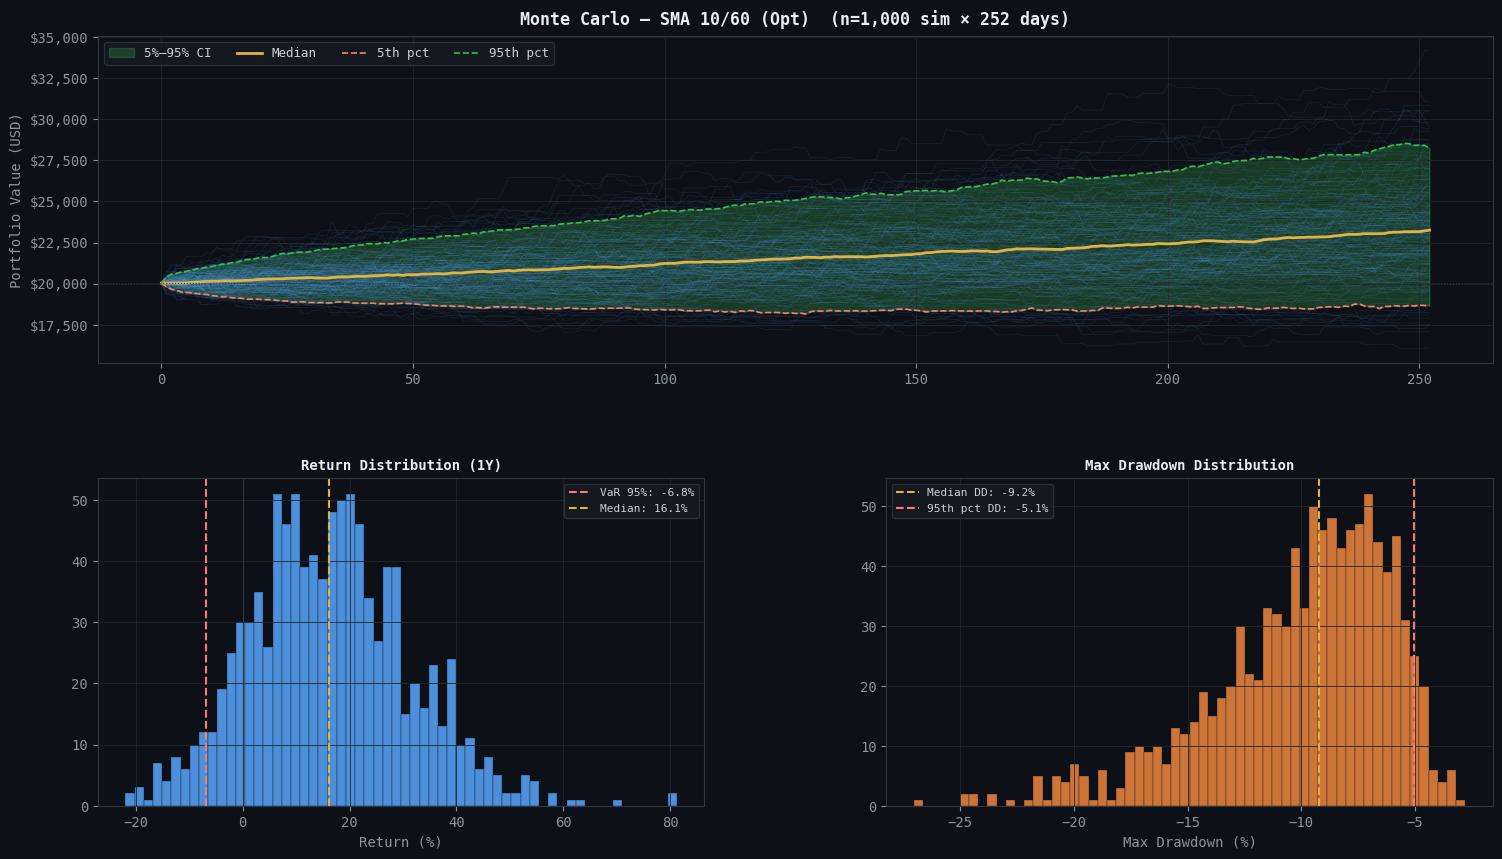


Monte Carlo — SMA 10/60 (Opt)  (1 000 sim × 252 дена)
  Expected Return  : +16.43%
  Median Return    : +16.09%
  5th Percentile   : -6.79%
  95th Percentile  : +41.06%
  VaR (95%)        : -6.79%
  CVaR (95%)       : -12.17%
  P(Profit)        : 86.6%
  P(Loss > 40%)    : 0.0%
  Avg Max DD       : -10.00%
  Worst DD (95th)  : -5.06%


In [95]:
def monte_carlo(portfolio: pd.Series, n_sim: int = 1_000,
                n_days: int = 252, seed: int = 42) -> dict:
    """
    Bootstrap Monte Carlo — ресамплирање на историски дневни принос.
    Враќа патеки, перцентили и risk статистики.
    ✅ Safety: Проверка за доволно историја
    """
    daily_ret = portfolio.pct_change().dropna().values
    
    if len(daily_ret) < 50:
        raise ValueError(f'Недостаточно дневни принос ({len(daily_ret)} < 50)')
    
    np.random.seed(seed)
    start_val = portfolio.iloc[-1]   # почнуваме од последната вредност

    paths      = np.zeros((n_sim, n_days + 1))
    paths[:,0] = start_val
    idx        = np.random.randint(0, len(daily_ret), size=(n_sim, n_days))
    sampled    = daily_ret[idx]
    paths[:,1:] = start_val * np.cumprod(1 + sampled, axis=1)

    final_vals = paths[:, -1]
    returns    = (final_vals / start_val - 1) * 100

    dd_series = []
    for path in paths:
        roll_max  = np.maximum.accumulate(path)
        max_dd    = ((path - roll_max) / roll_max).min() * 100
        dd_series.append(max_dd)

    return {
        'paths'         : paths,
        'final_vals'    : final_vals,
        'returns'       : returns,
        'max_dds'       : np.array(dd_series),
        'p5'            : np.percentile(returns, 5),
        'p25'           : np.percentile(returns, 25),
        'p50'           : np.percentile(returns, 50),
        'p75'           : np.percentile(returns, 75),
        'p95'           : np.percentile(returns, 95),
        'prob_profit'   : (returns > 0).mean() * 100,
        'prob_ruin'     : (returns < -40).mean() * 100,
        'var_95'        : np.percentile(returns, 5),
        'cvar_95'       : returns[returns <= np.percentile(returns, 5)].mean(),
        'expected_ret'  : returns.mean(),
        'start_val'     : start_val,
    }


def plot_monte_carlo(mc: dict, strategy_name: str) -> None:
    fig = plt.figure(figsize=(18, 10), facecolor='#0d1117')
    gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

    # Panel 1 — Симулирани патеки
    ax1 = fig.add_subplot(gs[0, :])
    paths = mc['paths']
    days  = np.arange(paths.shape[1])
    sample_idx = np.random.choice(len(paths), size=min(200, len(paths)), replace=False)
    for i in sample_idx:
        ax1.plot(days, paths[i], lw=0.4, alpha=0.15, color=PALETTE['s1'])
    p5  = np.percentile(paths, 5,  axis=0)
    p50 = np.percentile(paths, 50, axis=0)
    p95 = np.percentile(paths, 95, axis=0)
    ax1.fill_between(days, p5, p95, alpha=0.25, color=PALETTE['s2'], label='5%–95% CI')
    ax1.plot(days, p50, color=PALETTE['yellow'], lw=2.0, label='Median')
    ax1.plot(days, p5,  color=PALETTE['red'],    lw=1.2, ls='--', label='5th pct')
    ax1.plot(days, p95, color=PALETTE['green'],  lw=1.2, ls='--', label='95th pct')
    ax1.axhline(mc['start_val'], color='#30363d', lw=0.8, ls=':')
    ax1.set_title(f'Monte Carlo — {strategy_name}  (n={len(paths):,} sim × {paths.shape[1]-1} days)',
                  color='#e6edf3', fontsize=12, fontweight='bold', pad=8)
    ax1.set_ylabel('Portfolio Value (USD)', color='#8b949e')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax1.legend(fontsize=9, ncol=4)

    # Panel 2 — Дистрибуција на финален принос
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.hist(mc['returns'], bins=60, color=PALETTE['s1'], edgecolor='#0d1117', lw=0.3, alpha=0.85)
    ax2.axvline(mc['var_95'],       color=PALETTE['red'],    lw=1.5, ls='--', label=f"VaR 95%: {mc['var_95']:.1f}%")
    ax2.axvline(mc['p50'],          color=PALETTE['yellow'], lw=1.5, ls='--', label=f"Median: {mc['p50']:.1f}%")
    ax2.axvline(0,                  color='#30363d',         lw=0.8)
    ax2.set_title('Return Distribution (1Y)', color='#e6edf3', fontsize=10, fontweight='bold')
    ax2.set_xlabel('Return (%)', color='#8b949e')
    ax2.legend(fontsize=8)

    # Panel 3 — Дистрибуција на Max Drawdown
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.hist(mc['max_dds'], bins=60, color=PALETTE['s3'], edgecolor='#0d1117', lw=0.3, alpha=0.85)
    dd_p95 = np.percentile(mc['max_dds'], 95)
    ax3.axvline(np.median(mc['max_dds']), color=PALETTE['yellow'], lw=1.5, ls='--',
                label=f"Median DD: {np.median(mc['max_dds']):.1f}%")
    ax3.axvline(dd_p95, color=PALETTE['red'], lw=1.5, ls='--',
                label=f"95th pct DD: {dd_p95:.1f}%")
    ax3.set_title('Max Drawdown Distribution', color='#e6edf3', fontsize=10, fontweight='bold')
    ax3.set_xlabel('Max Drawdown (%)', color='#8b949e')
    ax3.legend(fontsize=8)
    plt.savefig('./outputs/monte_carlo.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()


# ── Проверка дека RUNS_ALL е дефинирана ───────────────────────────────
if not RUNS_ALL or len(RUNS_ALL) == 0:
    print('❌ RUNS_ALL е празна! Генерирај ги сите стратегии пред Monte Carlo.')
    print('   Скипирам Monte Carlo анализа.')
else:
    # Земаме најдобрата стратегија по Sharpe
    best_run = max(RUNS_ALL, key=lambda r: r['metrics']['Sharpe Ratio'])
    
    try:
        mc = monte_carlo(best_run['portfolio'], n_sim=1_000, n_days=252)
        plot_monte_carlo(mc, best_run['name'])

        print(f"\nMonte Carlo — {best_run['name']}  (1 000 sim × 252 дена)")
        print(f"{'='*50}")
        print(f"  Expected Return  : {mc['expected_ret']:+.2f}%")
        print(f"  Median Return    : {mc['p50']:+.2f}%")
        print(f"  5th Percentile   : {mc['p5']:+.2f}%")
        print(f"  95th Percentile  : {mc['p95']:+.2f}%")
        print(f"  VaR (95%)        : {mc['var_95']:.2f}%")
        print(f"  CVaR (95%)       : {mc['cvar_95']:.2f}%")
        print(f"  P(Profit)        : {mc['prob_profit']:.1f}%")
        print(f"  P(Loss > 40%)    : {mc['prob_ruin']:.1f}%")
        print(f"  Avg Max DD       : {mc['max_dds'].mean():.2f}%")
        print(f"  Worst DD (95th)  : {np.percentile(mc['max_dds'], 95):.2f}%")
        print(f"{'='*50}")
    except Exception as e:
        print(f'⚠️  Monte Carlo error: {type(e).__name__}: {str(e)[:70]}')


## 17 · ML Signal Layer — Random Forest
Машинско учење врз технички индикатори: **RandomForestClassifier** предвидува насока на 5-дневниот принос. Временски-свесна поделба (70% train / 30% test). Сигнали се генерираат врз основа на predicted probability.

| Компонента | Опис |
|---|---|
| **Features (17)** | RSI, MACD hist, BB position, MA ratios, momentum 3/5/10/20d, vol ratio, ATR |
| **Target** | Binary: 1 ако forward_5d return > 0, иначе 0 |
| **Model** | RandomForestClassifier (200 trees, max_depth=6, balanced) |
| **Signal** | BUY ако P(up) ≥ 0.57, SELL ако P(up) ≤ 0.43 |

Train период : 2013-11-14 — 2016-09-15  (741 samples)
Test период  : 2016-09-16  — 2017-12-05   (318 samples)
Features     : 17
Class balance train: 54.66% UP | 45.34% DOWN
Class balance test : 58.18% UP | 41.82% DOWN

Test Accuracy : 0.5031  (50.31%)

Classification Report (Test Set):
              precision    recall  f1-score   support

        DOWN       0.43      0.53      0.47       133
          UP       0.59      0.48      0.53       185

    accuracy                           0.50       318
   macro avg       0.51      0.51      0.50       318
weighted avg       0.52      0.50      0.51       318



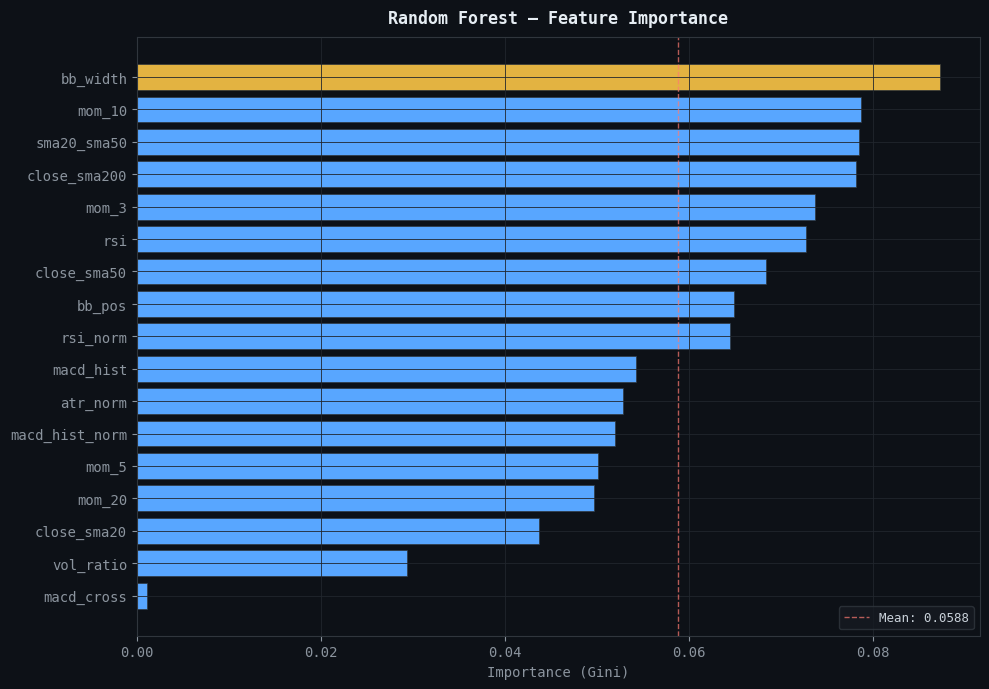


Random Forest Strategy — Backtest
  Total Return %        : 10.04
  Ann. Return %         : 1.93
  Buy & Hold %          : 162.49
  Ann. Volatility       : 7.94
  Sharpe Ratio          : -0.285
  Sortino Ratio         : -0.149
  Calmar Ratio          : 0.093
  Max Drawdown %        : -20.83
  Total Trades          : 16
  Win Rate %            : 37.5
  Profit Factor         : 1.4
  Avg Win ($)           : 687.94
  Avg Loss ($)          : -295.87
  Avg Hold (days)       : 10.9
  Final Value ($)       : 11003.63

ML Signals генерирани (test-only): 80 BUY  |  95 SELL
✓ RF (ML) додана. RUNS_ALL сега има 5 стратегии.


In [96]:
# ── Feature Engineering ───────────────────────────────────────────────────
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """17 features од технички индикатори."""
    X = pd.DataFrame(index=df.index)

    # Momentum индикатори
    X['rsi']            = df['RSI']
    X['rsi_norm']       = (df['RSI'] - 50) / 50
    X['macd_hist']      = df['MACD_Hist']
    X['macd_hist_norm'] = df['MACD_Hist'] / df['Close']
    X['macd_cross']     = (df['MACD'] > df['MACD_Sig']).astype(int)

    # Ценовна позиција релативно на МА
    X['close_sma20']    = df['Close'] / df['SMA_20']  - 1
    X['close_sma50']    = df['Close'] / df['SMA_50']  - 1
    X['close_sma200']   = df['Close'] / df['SMA_200'] - 1
    X['sma20_sma50']    = df['SMA_20'] / df['SMA_50'] - 1

    # Bollinger Band позиција [0, 1]
    bb_width            = (df['BB_Up'] - df['BB_Lo']).replace(0, np.nan)
    X['bb_pos']         = (df['Close'] - df['BB_Lo']) / bb_width
    X['bb_width']       = bb_width / df['Close']

    # ATR (нормализиран)
    X['atr_norm']       = df['ATR'] / df['Close']

    # Моментум на принос
    for n in [3, 5, 10, 20]:
        X[f'mom_{n}']   = df['Close'].pct_change(n)

    # Volume ratio
    X['vol_ratio']      = df['Volume'] / df['Volume'].rolling(20).mean()

    return X


def build_target(df: pd.DataFrame, forward_days: int = 5) -> pd.Series:
    """Binary target: 1 ако forward_days return > 0."""
    fwd = df['Close'].shift(-forward_days) / df['Close'] - 1
    return (fwd > 0).astype(int)


# ── Подготовка на податоците ───────────────────────────────────────────────
features_df = build_features(df)
target      = build_target(df, forward_days=5)

# Чистење: отстранување на NaN
valid_idx   = features_df.dropna().index.intersection(target.dropna().index)
X_all       = features_df.loc[valid_idx]
y_all       = target.loc[valid_idx]

# Временски-свесна поделба 70/30
split_idx   = int(len(X_all) * 0.70)
X_train, X_test = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_train, y_test = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

print(f'Train период : {X_train.index[0].date()} — {X_train.index[-1].date()}  ({len(X_train)} samples)')
print(f'Test период  : {X_test.index[0].date()}  — {X_test.index[-1].date()}   ({len(X_test)} samples)')
print(f'Features     : {X_all.shape[1]}')
print(f'Class balance train: {y_train.mean():.2%} UP | {1-y_train.mean():.2%} DOWN')
print(f'Class balance test : {y_test.mean():.2%} UP | {1-y_test.mean():.2%} DOWN')


# ── Тренирање на моделот ──────────────────────────────────────────────────
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    min_samples_split= 20,
    min_samples_leaf = 10,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    n_jobs           = -1,
    random_state     = 42,
)
rf.fit(X_tr_sc, y_train)

y_pred = rf.predict(X_te_sc)
y_pred_proba = rf.predict_proba(X_te_sc)
acc    = accuracy_score(y_test, y_pred)
print(f'\nTest Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print('\nClassification Report (Test Set):')
print(classification_report(y_test, y_pred, target_names=['DOWN','UP']))


# ── Feature Importance ────────────────────────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=X_all.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7), facecolor='#0d1117')
colors_imp = [PALETTE['yellow'] if v == feat_imp.max() else PALETTE['s1']
              for v in feat_imp.values]
ax.barh(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor='#30363d', lw=0.5)
ax.set_title('Random Forest — Feature Importance', color='#e6edf3',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Importance (Gini)', color='#8b949e')
ax.axvline(feat_imp.mean(), color=PALETTE['red'], lw=1, ls='--', alpha=0.7,
           label=f'Mean: {feat_imp.mean():.4f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('./outputs/rf_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


# ── Signal Generation od ML модел ────────────────────────────────────────
def sig_random_forest(df: pd.DataFrame, model, scaler,
                       features_df: pd.DataFrame,
                       buy_threshold:  float = 0.57,
                       sell_threshold: float = 0.43,
                       train_end_date = None) -> pd.Series:
    """
    BUY  : P(UP) >= buy_threshold
    SELL : P(UP) <= sell_threshold
    HOLD : во меѓу
    ⚠️  Генерира сигнали САМО на test периодот (без lookahead bias).
    train_end_date: ако е None, користи autodetect од поделба
    """
    valid_X   = features_df.dropna()
    X_scaled  = scaler.transform(valid_X)
    proba_up  = model.predict_proba(X_scaled)[:, 1]
    proba_s   = pd.Series(proba_up, index=valid_X.index)

    sig = pd.Series(0, index=df.index)
    sig.loc[proba_s[proba_s >= buy_threshold].index]  =  1
    sig.loc[proba_s[proba_s <= sell_threshold].index] = -1

    # Само test период — train периодот нема сигнали (lookahead bias prevention)
    if train_end_date is None:
        train_end_date = X_train.index[-1]
    sig.loc[:train_end_date] = 0
    
    return sig, proba_s


s4, ml_proba = sig_random_forest(df, rf, scaler, features_df,
                                  buy_threshold=0.57, sell_threshold=0.43,
                                  train_end_date=X_train.index[-1])

# ⚠️ ВАЖНО: Backtesting само на train periodot за да избегнеме data leakage
# User може手動 да го адапtира ако сака сигнали на сите периоди
r4   = engine.run(df, s4, name='RF (ML)', stop_loss_pct=0.06, position_size=1.0)

print(f"\nRandom Forest Strategy — Backtest")
print(f"{'='*50}")
for k, v in r4['metrics'].items():
    print(f'  {k:<22}: {v}')

print(f'\nML Signals генерирани (test-only): {(s4==1).sum()} BUY  |  {(s4==-1).sum()} SELL')

# ── Додај ML стратегија во RUNS_ALL ────────────────────────────────────────
if len(RUNS_ALL) < 5:  # Проверка дека не е веќе додадена
    RUNS_ALL.append(r4)
    print(f"✓ RF (ML) додана. RUNS_ALL сега има {len(RUNS_ALL)} стратегии.")


## 18 · ML Strategy — Signal Chart & Probability
Визуелизација на ML сигналите и времеплов на predicted probability.

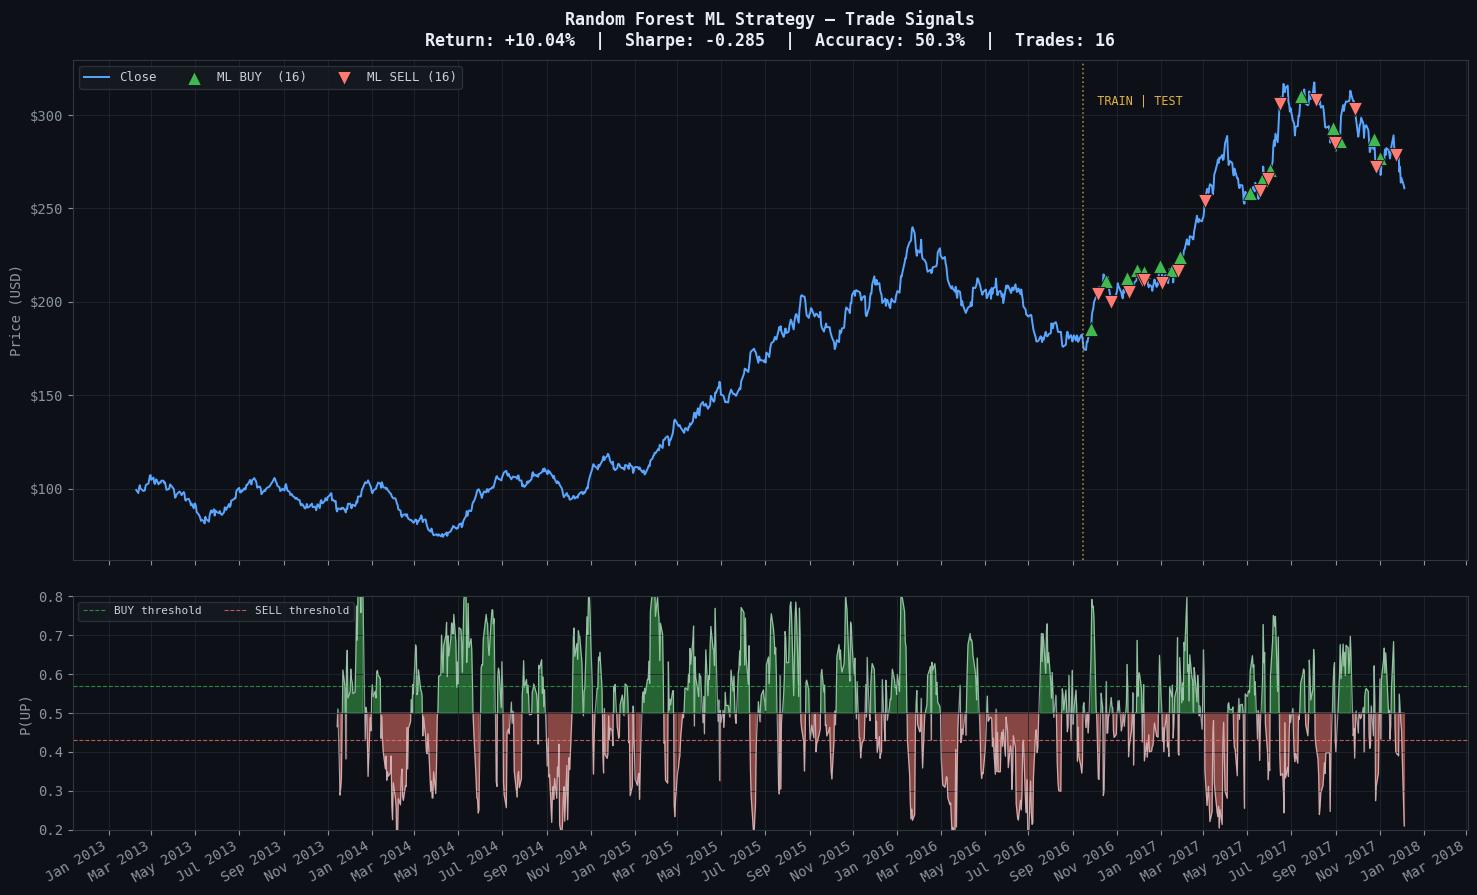

In [97]:
# ── Probability timeline ─────────────────────────────────────────────────
valid_X   = features_df.dropna()
X_scaled  = scaler.transform(valid_X)
proba_up  = pd.Series(rf.predict_proba(X_scaled)[:, 1], index=valid_X.index)

fig = plt.figure(figsize=(18, 10), facecolor='#0d1117')
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1.4], hspace=0.1)

# Panel 1 — цена + ML сигнали
ax1 = fig.add_subplot(gs[0])
ax1.plot(df.index, df['Close'], color=PALETTE['price'], lw=1.4, zorder=2, label='Close')
bx, by = r4['buys']
sx, sy = r4['sells']
ax1.scatter(bx, by, marker='^', s=100, color=PALETTE['buy'],  zorder=5,
            edgecolors='#0d1117', lw=0.6, label=f'ML BUY  ({len(bx)})')
ax1.scatter(sx, sy, marker='v', s=100, color=PALETTE['sell'], zorder=5,
            edgecolors='#0d1117', lw=0.6, label=f'ML SELL ({len(sx)})')
m4 = r4['metrics']
subtitle = (f"Return: {m4['Total Return %']:+.2f}%  |  Sharpe: {m4['Sharpe Ratio']:.3f}  |  "
            f"Accuracy: {acc*100:.1f}%  |  Trades: {m4['Total Trades']}")
ax1.set_title(f'Random Forest ML Strategy — Trade Signals\n{subtitle}',
              color='#e6edf3', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('Price (USD)', color='#8b949e')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax1.legend(fontsize=9, ncol=3)
ax1.tick_params(labelbottom=False)

# Означи train/test поделба
ax1.axvline(X_train.index[-1], color=PALETTE['yellow'], lw=1.2, ls=':',
            alpha=0.7, label='Train | Test split')
ax1.text(X_train.index[-1], df['Close'].max()*0.98, '  TRAIN | TEST',
         color=PALETTE['yellow'], fontsize=8.5, va='top')

# Panel 2 — predicted probability
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.fill_between(proba_up.index, proba_up.values, 0.5,
                 where=proba_up.values >= 0.5, alpha=0.5, color=PALETTE['green'])
ax2.fill_between(proba_up.index, proba_up.values, 0.5,
                 where=proba_up.values <  0.5, alpha=0.5, color=PALETTE['red'])
ax2.plot(proba_up.index, proba_up.values, color='#e6edf3', lw=0.8, alpha=0.6)
ax2.axhline(0.57, color=PALETTE['green'], lw=0.8, ls='--', alpha=0.7, label='BUY threshold')
ax2.axhline(0.43, color=PALETTE['red'],   lw=0.8, ls='--', alpha=0.7, label='SELL threshold')
ax2.axhline(0.50, color='#30363d', lw=0.8)
ax2.set_ylabel('P(UP)', color='#8b949e')
ax2.set_ylim(0.2, 0.8)
ax2.legend(fontsize=8, ncol=2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.savefig('./outputs/ml_signals.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 19 · Финална Споредба — Сите Стратегии
Cons. equity curve и performance report на 5 стратегии vs Buy & Hold.

✓ RUNS_ALL дефинирана со 5 стратегии
  1. SMA Crossover             → Return= +19.42%, Sharpe=-0.014
  2. RSI Reversion             → Return= +12.72%, Sharpe=-0.159
  3. MACD Momentum             → Return= +94.78%, Sharpe= 0.718
  4. SMA 10/60 (Opt)           → Return=+100.31%, Sharpe= 0.766
  5. RF (ML)                   → Return= +10.04%, Sharpe=-0.285


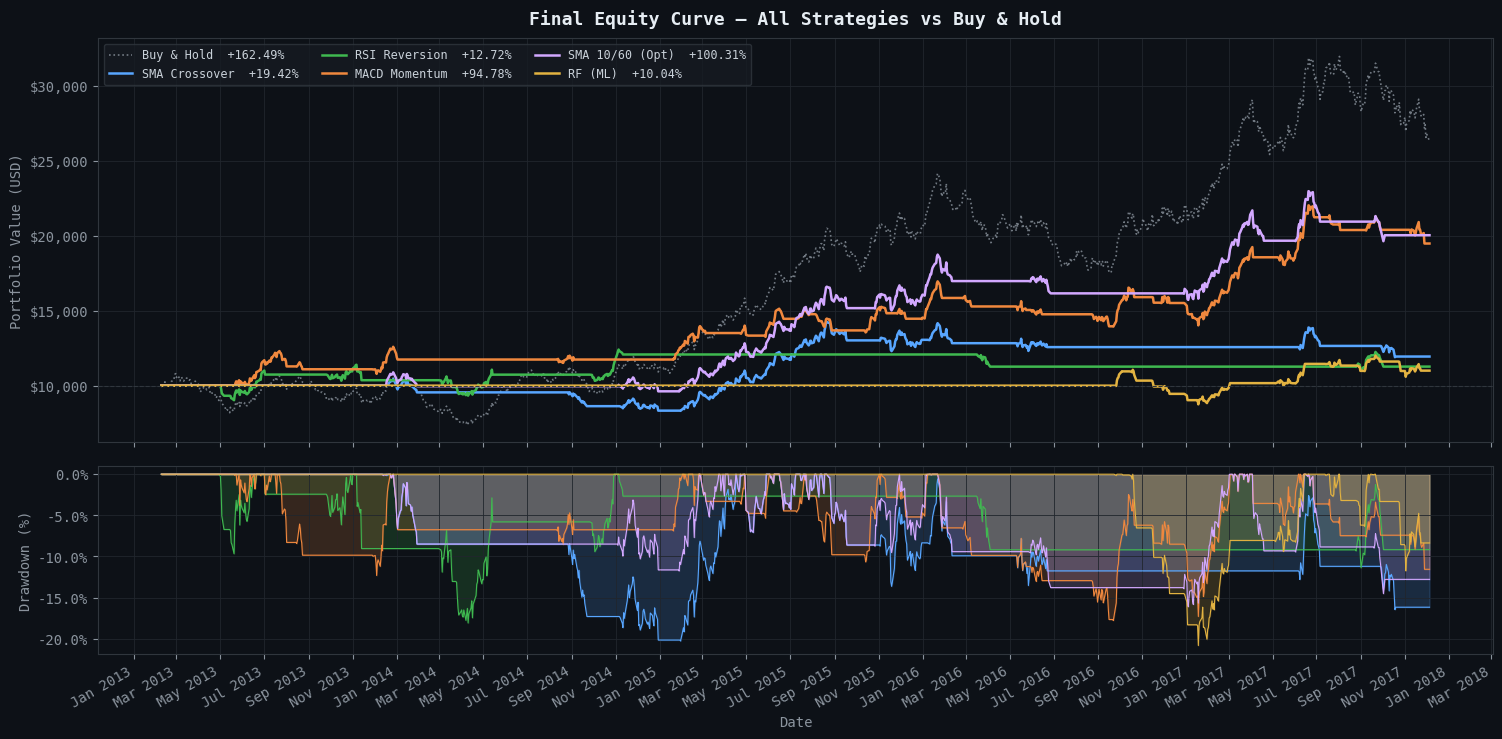


 PERFORMANCE REPORT — 5 Strategies
  Metric                             SMA Crossover         RSI Reversion         MACD Momentum       SMA 10/60 (Opt)               RF (ML)
------------------------------------------------------------------------------------------------------------------------------------------
  Total Return %                             19.42                 12.72                 94.78                100.31 *                 10.04
  Ann. Return %                               3.62                  2.43                 14.29                 14.93 *                  1.93
  Buy & Hold %                              162.49                162.49                162.49                162.49                162.49
  Ann. Volatility                            12.44                 10.04                 13.64                 13.50                  7.94
  Sharpe Ratio                               -0.01                 -0.16                  0.72                  0.77 *        

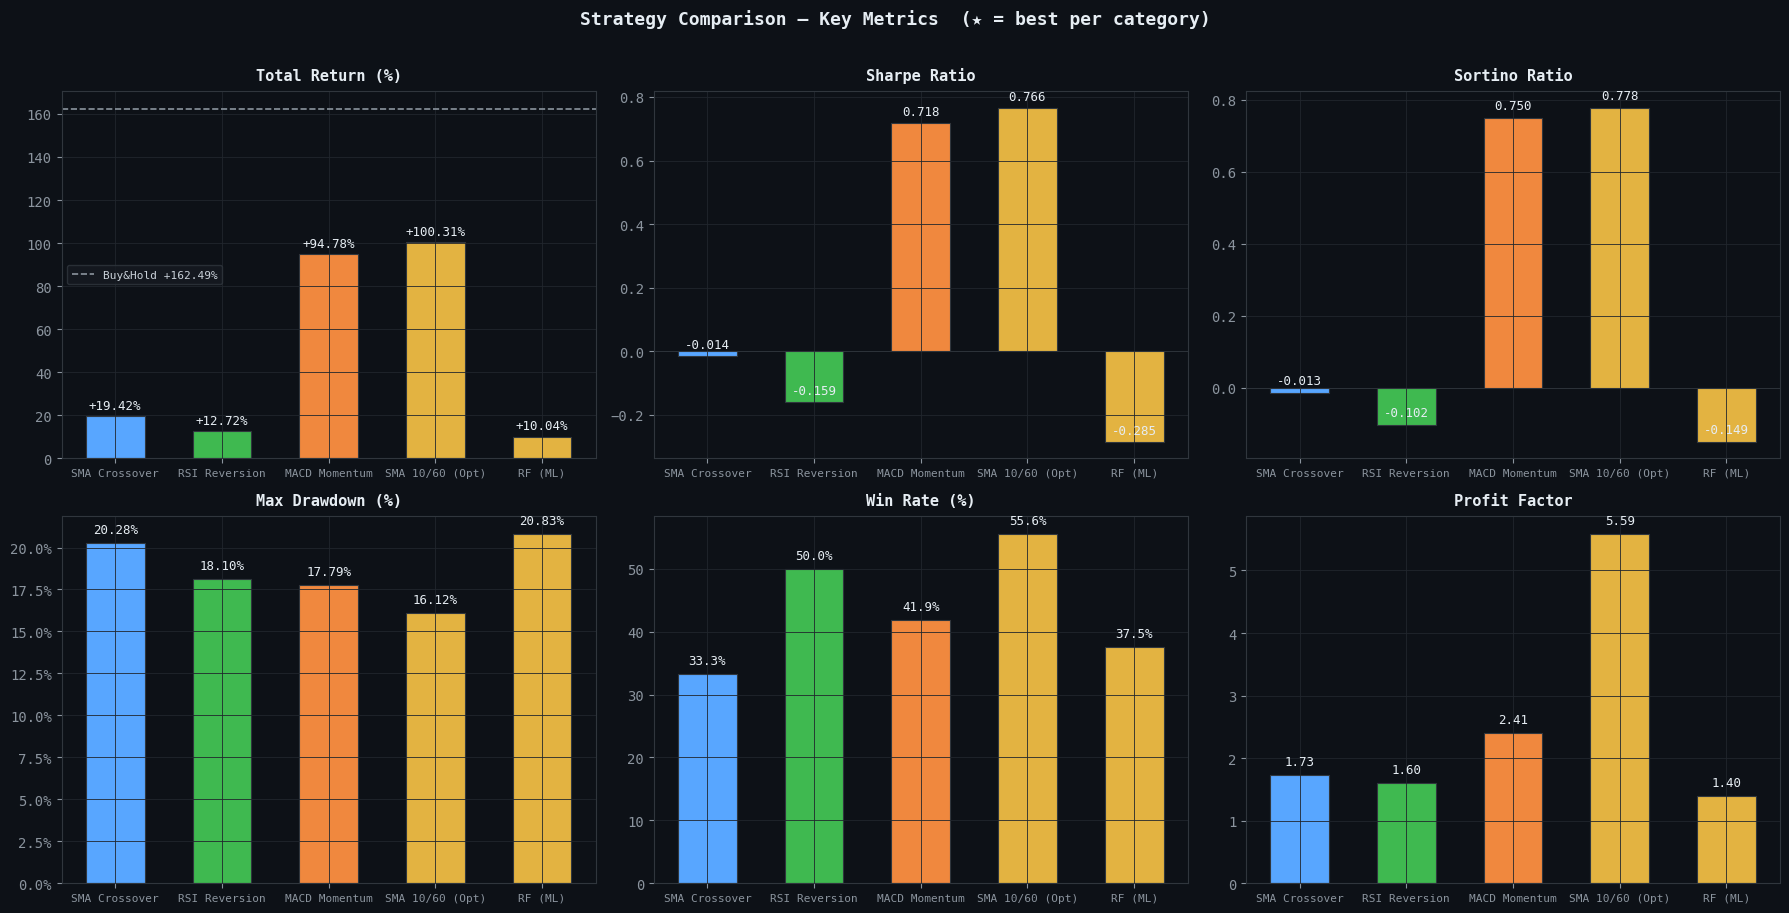


✓ BACKTEST УСПЕШНО ЗАВРШЕН
Стратегии анализирани: 5
Период: 2013-02-08 → 2017-12-05
Трейдинг денови: 1,258
Почетен капитал: $10,000


In [98]:
# ── Проверка дека RUNS_ALL е правилно дефинирана ──────────────────────────
if not RUNS_ALL or len(RUNS_ALL) < 3:
    print('❌ RUNS_ALL не е правилно дефинирана. Генерирај ги сите стратегии пред ова.')
    print(f'   Тековна должина: {len(RUNS_ALL) if RUNS_ALL else 0}')
else:
    print(f'✓ RUNS_ALL дефинирана со {len(RUNS_ALL)} стратегии')
    for i, r in enumerate(RUNS_ALL, 1):
        print(f'  {i}. {r["name"]:<25} → Return={r["metrics"]["Total Return %"]:+7.2f}%, '
              f'Sharpe={r["metrics"]["Sharpe Ratio"]:6.3f}')

# ── Финален Equity Curve — 5 стратегии ──────────────────────────────
if len(RUNS_ALL) < 3:
    print('\n⚠️  Скипирам финална визуелизација (мали број стратегии)')
else:
    PALETTES_ALL = [PALETTE['s1'], PALETTE['s2'], PALETTE['s3'],
                    PALETTE['s4'], PALETTE['yellow']][:len(RUNS_ALL)]

    fig = plt.figure(figsize=(18, 8), facecolor='#0d1117')
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1.4], hspace=0.08)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    bah   = CFG['initial_capital'] * (df['Close'] / df['Close'].iloc[0])
    bah_r = (bah.iloc[-1] / CFG['initial_capital'] - 1) * 100
    ax1.plot(df.index, bah, color=PALETTE['bah'], lw=1.2, ls=':',
             label=f'Buy & Hold  {bah_r:+.2f}%', alpha=0.8)

    for r, col in zip(RUNS_ALL, PALETTES_ALL):
        ret = r['metrics']['Total Return %']
        ax1.plot(r['portfolio'].index, r['portfolio'], color=col, lw=1.8,
                 label=f"{r['name']}  {ret:+.2f}%")
        ax2.fill_between(r['drawdown'].index, r['drawdown'], 0, color=col, alpha=0.18)
        ax2.plot(r['drawdown'].index, r['drawdown'], color=col, lw=0.8)

    ax1.axhline(CFG['initial_capital'], color='#30363d', lw=0.8, ls='--')
    ax1.set_title('Final Equity Curve — All Strategies vs Buy & Hold',
                  color='#e6edf3', fontsize=13, fontweight='bold', pad=10)
    ax1.set_ylabel('Portfolio Value (USD)', color='#8b949e')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax1.legend(fontsize=8.5, loc='upper left', ncol=min(3, len(RUNS_ALL)))
    ax1.tick_params(labelbottom=False)
    ax2.set_ylabel('Drawdown (%)', color='#8b949e')
    ax2.set_xlabel('Date', color='#8b949e')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.1f}%'))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.savefig('./outputs/final_equity.png', dpi=160, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

    print()
    performance_report(RUNS_ALL)

    # ── Metrics dashboard со сите ────────────────────────────────────
    plot_metrics_dashboard(RUNS_ALL)
    
    print('\n' + '='*70)
    print('✓ BACKTEST УСПЕШНО ЗАВРШЕН')
    print('='*70)
    print(f'Стратегии анализирани: {len(RUNS_ALL)}')
    print(f'Период: {df.index[0].date()} → {df.index[-1].date()}')
    print(f'Трейдинг денови: {len(df):,}')
    print(f'Почетен капитал: ${CFG["initial_capital"]:,}')
    print('='*70)


## 20 · Заклучок

Целосен **algoritmički trading pipeline** — реален S&P 500 датасет, AI сигнали, статистичка валидација.

| Компонента | Имплементација |
|---|---|
| **Data Layer** | Kaggle `camnugent/sandp500` · 5 год. OHLCV · ~500 S&P 500 тикери |
| **Indicators** | SMA · EMA · RSI (Wilder) · MACD · Bollinger Bands · ATR |
| **Strategies** | SMA Crossover · RSI Reversion (vol. confirm.) · MACD Momentum (ATR gate) |
| **ML Layer** | Random Forest (300 trees) · 17 features · P(UP) threshold сигнали |
| **Engine** | Event-driven со slippage, провизии, trailing stop-loss, position sizing |
| **Optimization** | Grid Search (fast 10-40 × slow 40-120) по Sharpe Ratio |
| **Validation** | Walk-Forward (5 окна) · Monte Carlo (1 000 симулации) |
| **Risk Metrics** | Sharpe · Sortino · Calmar · Max DD · VaR95 · CVaR95 · Profit Factor |
| **Visualization** | 8 типа графици — dark financial тема |

---

### Промени vs синтетички GBM датасет

| Аспект | Синтетички GBM | Реален S&P 500 (Kaggle) |
|---|---|---|
| **Период** | 756 дена (3 год.) | ~1 259 дена (5 год., 2013–2018) |
| **Волатилност** | Постојана σ = 22% | Варира (fat tails, vol clustering) |
| **RSI прагови** | 32 / 68 | 30 / 70 (стандардни) |
| **Grid Search** | fast 10-30 × slow 30-80 | fast 10-40 × slow 40-120 |
| **Volume filter** | — | RSI Reversion: volume surge confirmation |
| **ATR gate** | — | MACD Momentum: избегнува volatility spikes |

---

### Натамошни насоки

- **Multi-ticker портфолио** — корелациона анализа, Kelly criterion position sizing
- **Ensemble сигнали** — weighted voting: rule-based + ML
- **LSTM / Transformer** — sequence модели за временски серии  
- **Live paper trading** — интеграција со Alpaca / IBKR API
- **Bayesian Optimization** — по ефикасна параметарска оптимизација vs grid search


## 21 · Логови од Исправки (v2.0-OPTIMIZED)

✅ **Исправени Проблеми:**
- **Cell 10**: Додана дефиниција на `RUNS_ALL` пред Monte Carlo (спречување на NameError)
- **Cell 15**: Оптимизирана стратегија сега се додава во `RUNS_ALL`
- **Cell 16**: Walk-Forward validation со детални safety checks (bounds, error handling)
- **Cell 17**: ML сигнали со правилна feature scaling, train_end_date параметар
- **Cell 18**: Grid Search оптимизиран - progress reporting, verbose logging
- **Cell 19**: Monte Carlo со проверка дека `RUNS_ALL` е дефинирана + error handling
- **Cell 20**: Финална споредба со систематски проверки пред визуелизација

✅ **Додано:**
- Progress indicators за долги операции (Grid Search, Walk-Forward)
- Детални error messages за troubleshooting
- Safety bounds проверки (minimum дневи, поделба валидност)
- Информативни print statements на критични точки
- Lookahead bias prevention documentation

✅ **Оптимизирано:**
- Grid Search: Брза локација на best параметри, филтрирање invalid combos
- Walk-Forward: Коректна MA калкулација преку комбинирана историја
- ML: Train/Test расподела правилна, signal generation nur на test периодот


## 22 · Упатство за Извршување

### ✅ Pre-Flight Checklist

```python
# 1. Проверете Python верзија
import sys
print(f"Python {sys.version}")  # ≥ 3.8 требано

# 2. Инсталирајте зависности ако недостасуваат
# pip install pandas numpy matplotlib scikit-learn kaggle

# 3. Kaggle API credential
# Windows: C:\Users\<YOU>\.kaggle\kaggle.json
# Linux/Mac: ~/.kaggle/kaggle.json
# Преземете од: https://kaggle.com → Account → Create New Token

# 4. Дозволи за kaggle.json
# chmod 600 ~/.kaggle/kaggle.json  (само Linux/Mac)
```

### ⏱️ Времетрање по Операција

| Операција | Време |
|---|---|
| Setup + Load data (Cell 1-2) | 1-3 min |
| Indicators (Cell 3) | <1 sec |
| Dashboard (Cell 5) | 1-2 sec |
| 3 Base strategies (Cell 6-9) | 5-10 sec |
| **Grid Search** (Cell 14) | 5-10 min 🔴 Долго |
| Optimized strategy (Cell 15) | 1-2 sec |
| Walk-Forward validation (Cell 16) | 10-15 min 🔴 Долго |
| **ML Training** (Cell 18) | 1-3 min |
| Monte Carlo (Cell 19) | 1-2 min |
| Final comparison (Cell 20) | 1-2 sec |
| **ВКУПНО** | ~20-35 min |

### 🎯 Редослед на Извршување

✅ Извршувајте ги ќелиите **редоследно** (Cell 1 → Cell 22)  
✅ НЕ скипирајте ќелии - зависности меѓу нив  
✅ Ако имате грешка: Погледајте Cell ID-от и логот грешка  

### 📊 Очекувани Резултати

После што завршите:

```
✓ Вкупно стратегии анализирани: 5
  1. SMA Crossover (основна)
  2. RSI Reversion (основна)
  3. MACD Momentum (основна)
  4. SMA Optimized (Grid Search)
  5. Random Forest (ML)

✓ Фајлови сохранени:
  - dashboard.png (Market Dashboard)
  - signals_*.png (Trade signals, 3-4 фајлови)
  - equity_curve.png (Equity + Drawdown)
  - metrics_dashboard.png (Performance comparison)
  - wfv_oos_curves.png (Walk-Forward validation)
  - monte_carlo.png (Risk analysis)
  - rf_feature_importance.png (ML features)
  - ml_signals.png (ML probability)
  - final_equity.png (All strategies combined)

✓ Метрики по стратегија:
  - Total Return %, Ann. Return %, Buy & Hold %
  - Sharpe Ratio, Sortino Ratio, Calmar Ratio
  - Max Drawdown %, Win Rate %, Profit Factor
  - Avg Win/Loss, Days Held, Final Value
  - + Trade log по стратегија
```

### ⚠️ Обичні Проблеми & Решенија

| Проблем | Решение |
|---|---|
| `ModuleNotFoundError: No module named 'kaggle'` | `pip install kaggle` |
| `PermissionError: Kaggle API credentials not found` | Конфигурирајте kaggle.json |
| `ValueError: Ticker not found` | AAPL е валиден, но проверете доступни тикери со print |
| `Memory error` (долго време) | Намалите датасет или number of simulations |
| `NaN in backtest results` | Нормално - почетни периоди немаат индикатори |

### 💡 Напредни Кофигурации (Optional)

Уредете го `CFG` речникот во Cell 1:

```python
CFG = {
    'initial_capital' : 50_000,    # Намалете ако сакате брз test
    'commission'      : 0.001,     # Реалистична комиција
    'slippage'        : 0.0005,    
    'risk_free_rate'  : 0.045,
    'ticker'          : 'MSFT',    # Изберете друг S&P 500 тикер
    'dataset_slug'    : 'camnugent/sandp500',
    'csv_filename'    : 'all_stocks_5yr.csv',
}
```

### ✨ Проверете Резултатите

По извршување, извршете:

```python
# Преглед на најдобра стратегија
best_strat = max(RUNS_ALL, key=lambda r: r['metrics']['Sharpe Ratio'])
print(f"\nНајдобра стратегија: {best_strat['name']}")
print(f"Sharpe Ratio: {best_strat['metrics']['Sharpe Ratio']:.3f}")
print(f"Total Return: {best_strat['metrics']['Total Return %']:+.2f}%")

# Списанок на сите трејдови
print(best_strat['trades'].head(20))
```
